# Browse Unified OUTRIDER-Style Outliers

Loads the unified outliers table from `runs/clinical_methods_37M/unified_outliers.tsv` and produces OUTRIDER-style visualizations: volcano plots per sample, gene rank plots across the cohort, recall of causal genes, QQ plots, observed vs predicted distributions, and method comparison.

## Analysis types

| Analysis | Scope | Description |
|----------|-------|-------------|
| **Volcano plots** | **Single sample** | For one sample: genes on X (z-score) vs Y (-log10 p-value). Ranks genes within that sample. |
| **Gene rank plots** | **Cohort** | For one gene: samples on X (rank by anomaly) vs Y (z-score/residual). Ranks samples across the full cohort. |
| **Recall, QQ, method summary** | **Cohort** | Aggregate metrics across all samples and genes. |

- **Single-sample analysis:** One patient at a time. Answers: *Which genes are most anomalous in this sample?* (volcano, table browsing).
- **Cohort analysis:** All samples together. Answers: *Which samples are most anomalous for this gene?* (gene rank) or *How well do methods recover known causal genes?* (recall, QQ).

**Requires:** Run `scripts/export_unified_clinical_outliers.py` first to generate the unified TSV.

## 1. Setup and Load

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..").resolve() if (Path("..").resolve() / "bulkformer_dx").exists() else Path(".").resolve()
UNIFIED_TSV = ROOT / "runs" / "clinical_methods_37M" / "unified_outliers.tsv"
FIGURES_DIR = ROOT / "reports" / "figures" / "unified_outliers_browse"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not UNIFIED_TSV.exists():
    raise FileNotFoundError(
        f"Unified TSV not found: {UNIFIED_TSV}\n"
        "Run: python scripts/export_unified_clinical_outliers.py"
    )
df = pd.read_csv(UNIFIED_TSV, sep="\t")

# Infer METHODS from column prefixes (e.g. none_z_score -> none)
z_cols = [c for c in df.columns if c.endswith("_z_score")]
METHODS = sorted({c.replace("_z_score", "") for c in z_cols})

n_samples = df["SampleID"].nunique()
n_genes = df["GeneID"].nunique()
samples_with_causal = df.dropna(subset=["known_causal_gene"]).groupby("SampleID").first().reset_index()["SampleID"].nunique()

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Samples: {n_samples} | Genes: {n_genes}")
print(f"Samples with known causal gene: {samples_with_causal}")
print(f"Methods: {METHODS}")

Shape: 2,805,732 rows x 45 columns
Samples: 146 | Genes: 19751
Samples with known causal gene: 54
Methods: ['knn_local', 'nb_approx', 'nb_outrider', 'nll', 'none', 'student_t']


### Interactive inputs

Set `gene_name` for **gene rank plots** (cohort: value vs sample rank) or `sample_id` for **volcano plots** (single sample: genes ranked per sample), then run the corresponding cells.

**Causal gene examples for rank plots (cohort):** EPG5, FDXR, TIMMDC1, DNAJC30, NDUFB11, LIG3, ACAD9, MORC2, MT-ND5, MRPL38, SSBP1, NFU1

**Sample examples for volcano plots (single-sample):** OM06865 (EPG5), OM23417 (FDXR), OM38813 (TIMMDC1), OM43933 (DNAJC30), OM87369 (NDUFB11), OM91786 (LIG3), OM65708 (ACAD9), OM27390 (MORC2), OM32691 (MT-ND5)

In [23]:
# Gene rank plots (cohort): EPG5, FDXR, TIMMDC1, DNAJC30, NDUFB11, LIG3, ACAD9, MORC2, MT-ND5, MRPL38, SSBP1, NFU1
gene_name = "TIMMDC1"

# Volcano plots (single-sample): OM06865(EPG5), OM23417(FDXR), OM38813(TIMMDC1), OM43933(DNAJC30), OM87369(NDUFB11), OM91786(LIG3), OM65708(ACAD9), OM27390(MORC2), OM32691(MT-ND5)
sample_id = "OM38813"

## 2. Table Browsing (single sample)

**Scope:** Single sample. Filter by sample and gene; display top N rows sortable by p-value or z-score. Rows where `is_known_causal_gene == True` are highlighted. Use this to inspect which genes are most anomalous in a given sample.

In [24]:
def browse_table(
    data: pd.DataFrame,
    sample_id: str | None = None,
    gene_filter: str | None = None,
    method: str = "none",
    sort_by: str = "p_value",
    top_n: int = 50,
) -> pd.DataFrame:
    """Filter and sort unified outliers for display."""
    out = data.copy()
    if sample_id:
        out = out[out["SampleID"] == sample_id]
    if gene_filter:
        g = gene_filter.lower()
        out = out[
            out["Gene_Name"].fillna("").str.lower().str.contains(g, na=False)
            | out["GeneID"].astype(str).str.lower().str.contains(g, na=False)
        ]
    pcol = f"{method}_raw_p_value"
    zcol = f"{method}_z_score"
    if pcol not in out.columns or zcol not in out.columns:
        return out.head(top_n)
    if sort_by == "p_value":
        out = out.sort_values(pcol, ascending=True, na_position="last")
    else:
        out = out.sort_values(zcol, key=abs, ascending=False, na_position="last")
    return out.head(top_n)

# Uses sample_id from interactive inputs above
browsed = browse_table(df, sample_id=sample_id, method="none", sort_by="p_value", top_n=30)
display_cols = ["SampleID", "GeneID", "Gene_Name", "is_known_causal_gene", "observed_log1p_tpm"]
for m in METHODS:
    if f"{m}_z_score" in df.columns:
        display_cols.append(f"{m}_z_score")
    if f"{m}_raw_p_value" in df.columns:
        display_cols.append(f"{m}_raw_p_value")
display_cols = [c for c in display_cols if c in browsed.columns]
# Highlight causal rows
def highlight_causal(row):
    return ["background-color: #ffe0e0" if row["is_known_causal_gene"] else ""] * len(row)
browsed[display_cols].style.apply(highlight_causal, axis=1)

,SampleID,GeneID,Gene_Name,is_known_causal_gene,observed_log1p_tpm,knn_local_z_score,knn_local_raw_p_value,nb_approx_z_score,nb_approx_raw_p_value,nb_outrider_z_score,nb_outrider_raw_p_value,nll_z_score,nll_raw_p_value,none_z_score,none_raw_p_value,student_t_z_score,student_t_raw_p_value
930197,OM38813,ENSG00000121905,HPCA,False,0.015326,nan,nan,nan,nan,nan,nan,nan,nan,-15.592724,0.000000,nan,nan
2030288,OM38813,ENSG00000106565,TMEM176B,False,3.548776,nan,nan,nan,nan,nan,nan,9.156746,0.000000,14.639612,0.000000,nan,nan
1217396,OM38813,ENSG00000002933,TMEM176A,False,3.551366,7.667630,0.000000,5.702297,0.000000,5.702297,0.000000,9.692617,0.000000,13.248339,0.000000,5.702297,0.002315
2347293,OM38813,ENSG00000174697,LEP,False,2.516513,nan,nan,nan,nan,nan,nan,15.306523,0.000000,12.129585,0.000000,nan,nan
183704,OM38813,ENSG00000137975,CLCA2,False,1.590724,nan,nan,nan,nan,nan,nan,8.464688,0.000000,11.970864,0.000000,nan,nan
1390762,OM38813,ENSG00000108381,ASPA,False,2.161552,nan,nan,nan,nan,nan,nan,9.922119,0.000000,10.405073,0.000000,nan,nan
2264515,OM38813,ENSG00000174059,CD34,False,2.592030,nan,nan,nan,nan,nan,nan,11.427540,0.000000,10.305157,0.000000,nan,nan
537223,OM38813,ENSG00000182389,CACNB4,False,0.857203,nan,nan,nan,nan,nan,nan,nan,nan,9.894341,0.000000,nan,nan
2673385,OM38813,ENSG00000138615,CILP,False,2.190517,6.283920,0.000000,4.369811,0.000012,4.369811,0.000012,0.653954,0.513142,9.240705,0.000000,4.369811,0.007223
1763423,OM38813,ENSG00000110723,EXPH5,False,1.162081,nan,nan,nan,nan,nan,nan,3.895228,0.000098,9.158612,0.000000,nan,nan


## 3. Volcano Plots (single sample)

**Scope:** Single sample. Ranks **genes** within that sample.

For the selected sample: X = z-score, Y = -log10(raw p-value). Each point is a gene. Causal genes (where `Gene_Name == known_causal_gene` for that sample) highlighted in red. One subplot per calibration method.

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM38813.png


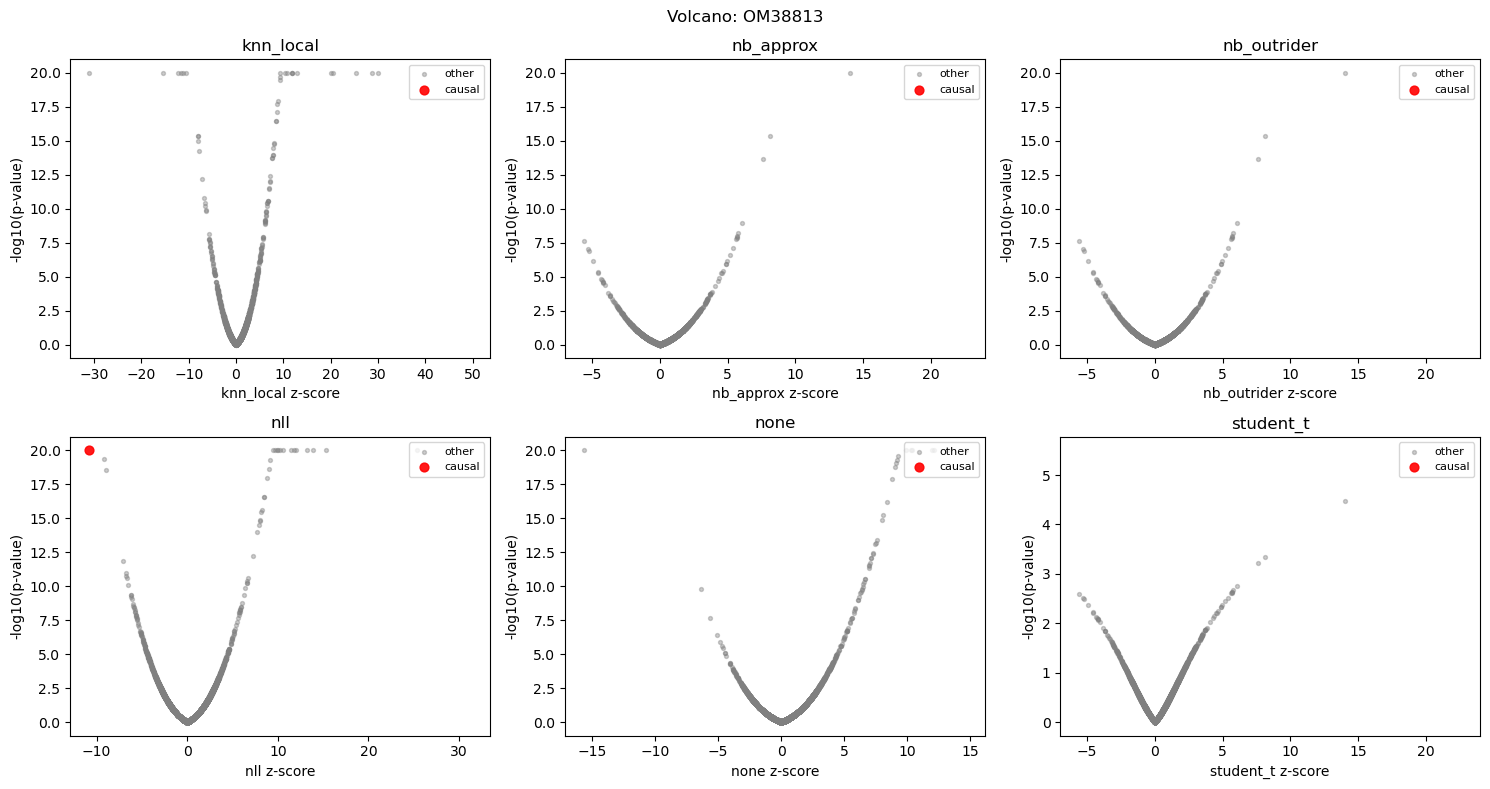

In [25]:
def plot_volcano_per_sample(data: pd.DataFrame, sample_id: str, methods: list[str], cap_neglog10: float = 20.0):
    sub = data[data["SampleID"] == sample_id].copy()
    if sub.empty:
        print(f"No data for sample {sample_id}")
        return None
    n = len(methods)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.ravel()
    for i, method in enumerate(methods):
        ax = axes[i]
        zcol = f"{method}_z_score"
        pcol = f"{method}_raw_p_value"
        if zcol not in sub.columns or pcol not in sub.columns:
            ax.text(0.5, 0.5, f"{method}: no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(method)
            continue
        z = sub[zcol].fillna(0).values
        p = sub[pcol].replace(0, 1e-300).values
        neglog10 = -np.log10(np.clip(p, 1e-300, 1))
        neglog10 = np.clip(neglog10, 0, cap_neglog10)
        causal = sub["is_known_causal_gene"].fillna(False).values
        ax.scatter(z[~causal], neglog10[~causal], alpha=0.4, s=8, c="gray", label="other")
        if causal.any():
            ax.scatter(z[causal], neglog10[causal], alpha=0.9, s=40, c="red", label="causal", zorder=5)
        ax.set_xlabel(f"{method} z-score")
        ax.set_ylabel("-log10(p-value)")
        ax.set_title(method)
        ax.legend(loc="upper right", fontsize=8)
    for j in range(len(methods), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"Volcano: {sample_id}", fontsize=12)
    fig.tight_layout()
    out_path = FIGURES_DIR / f"volcano_{sample_id}.png"
    fig.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")
    return fig

fig = plot_volcano_per_sample(df, sample_id, METHODS)
if fig is not None:
    plt.show()

## 4. Gene Rank Plots (cohort)

**Scope:** Full cohort. Ranks **samples** by how anomalous the selected gene is in each sample.

For the selected gene: X = sample rank (1 = most anomalous for that gene), Y = z-score (or residual). Each point is a sample. Causal samples (where this gene is the known causal gene) highlighted in red. One subplot per calibration method. Ideal for causal genes (EPG5, FDXR, TIMMDC1, etc.) to see if the true-positive sample ranks high.

### Run multiple examples (optional)

Run the cell below to generate:
- **Volcano plots (single-sample):** For several samples with known causal genes — shows which genes are most anomalous in each sample.
- **Gene rank plots (cohort):** For several causal genes — shows which samples rank highest for each gene across the full cohort.

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM06865.png


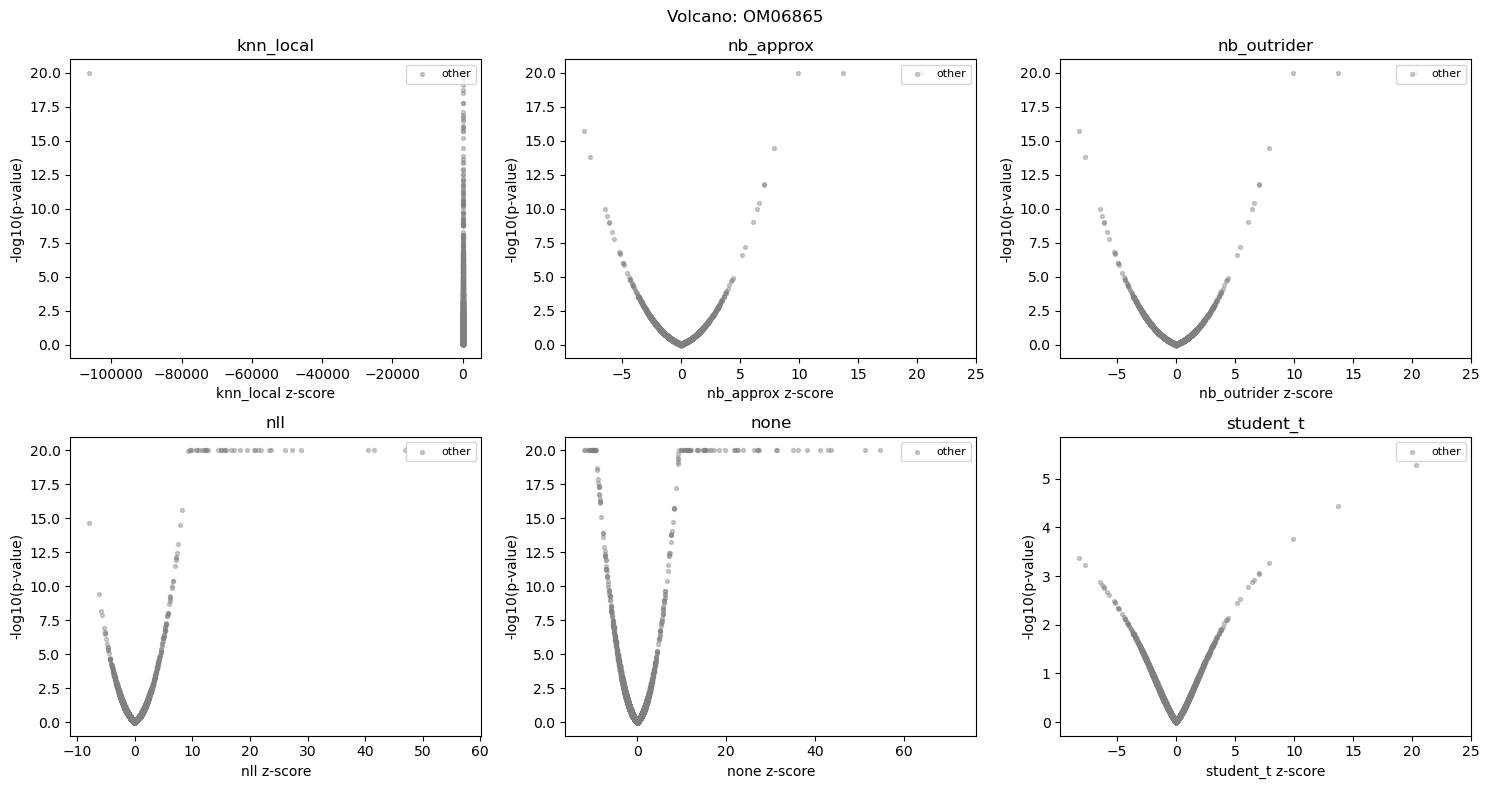

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM23417.png


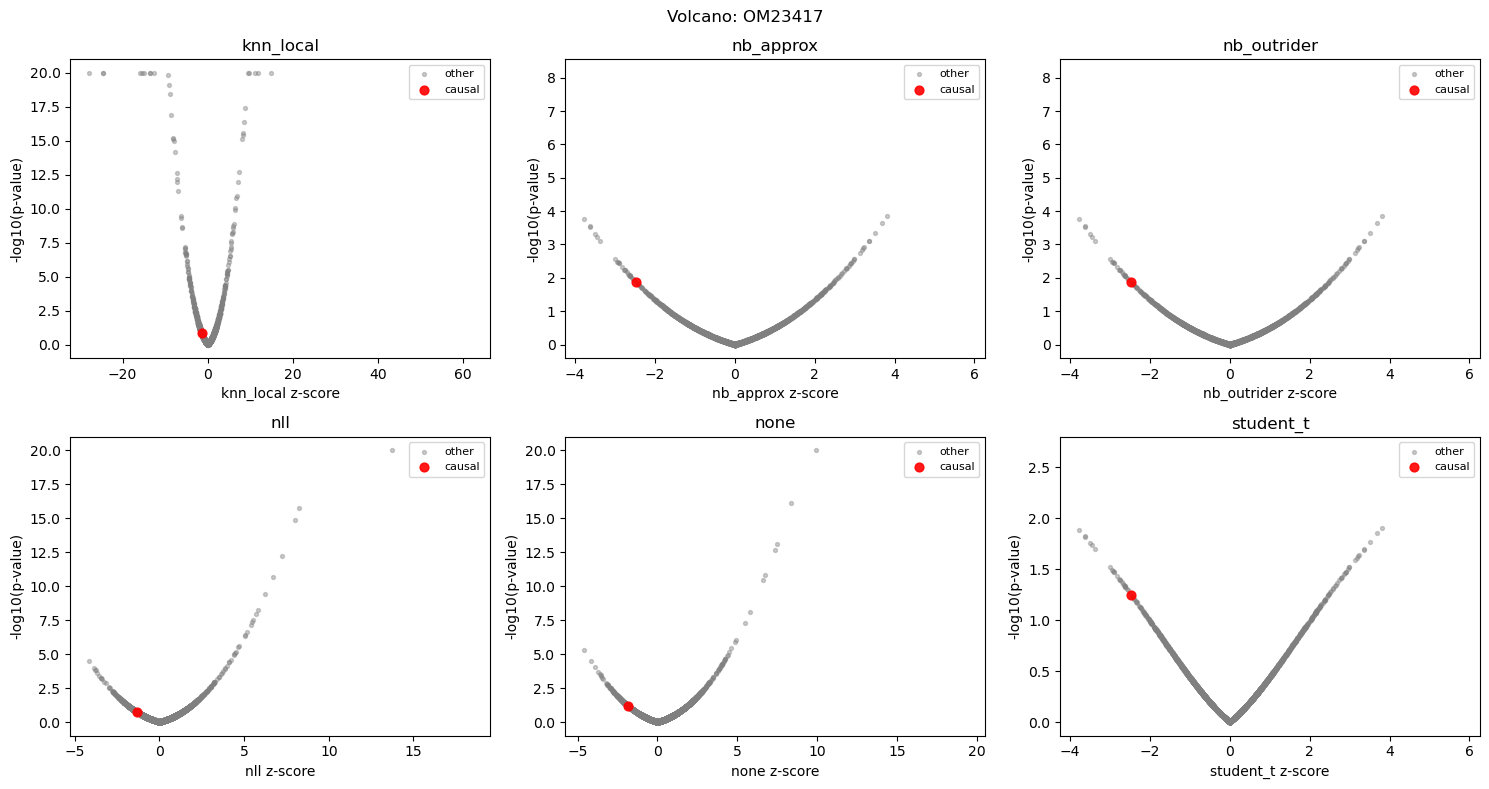

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM38813.png


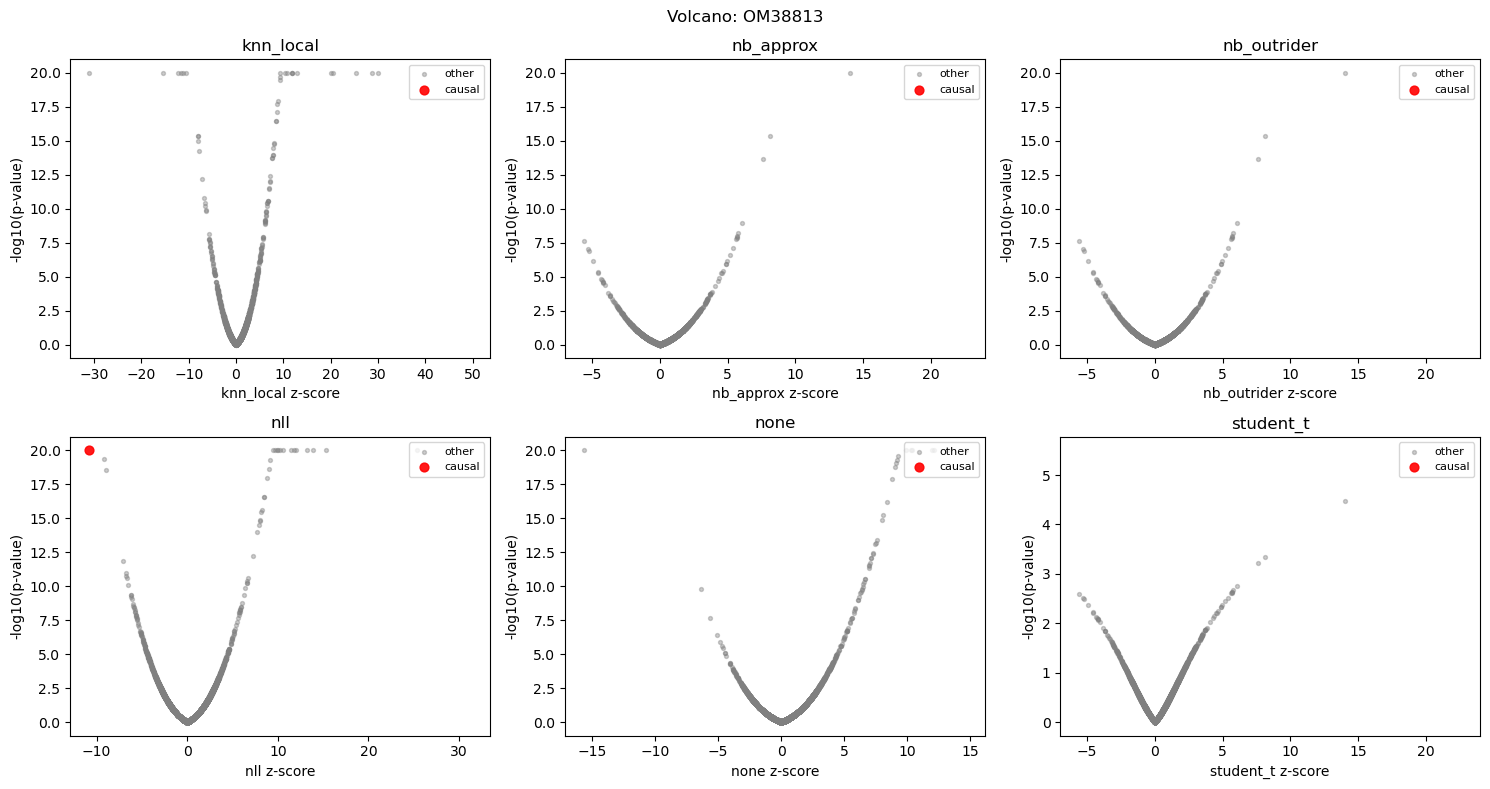

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM43933.png


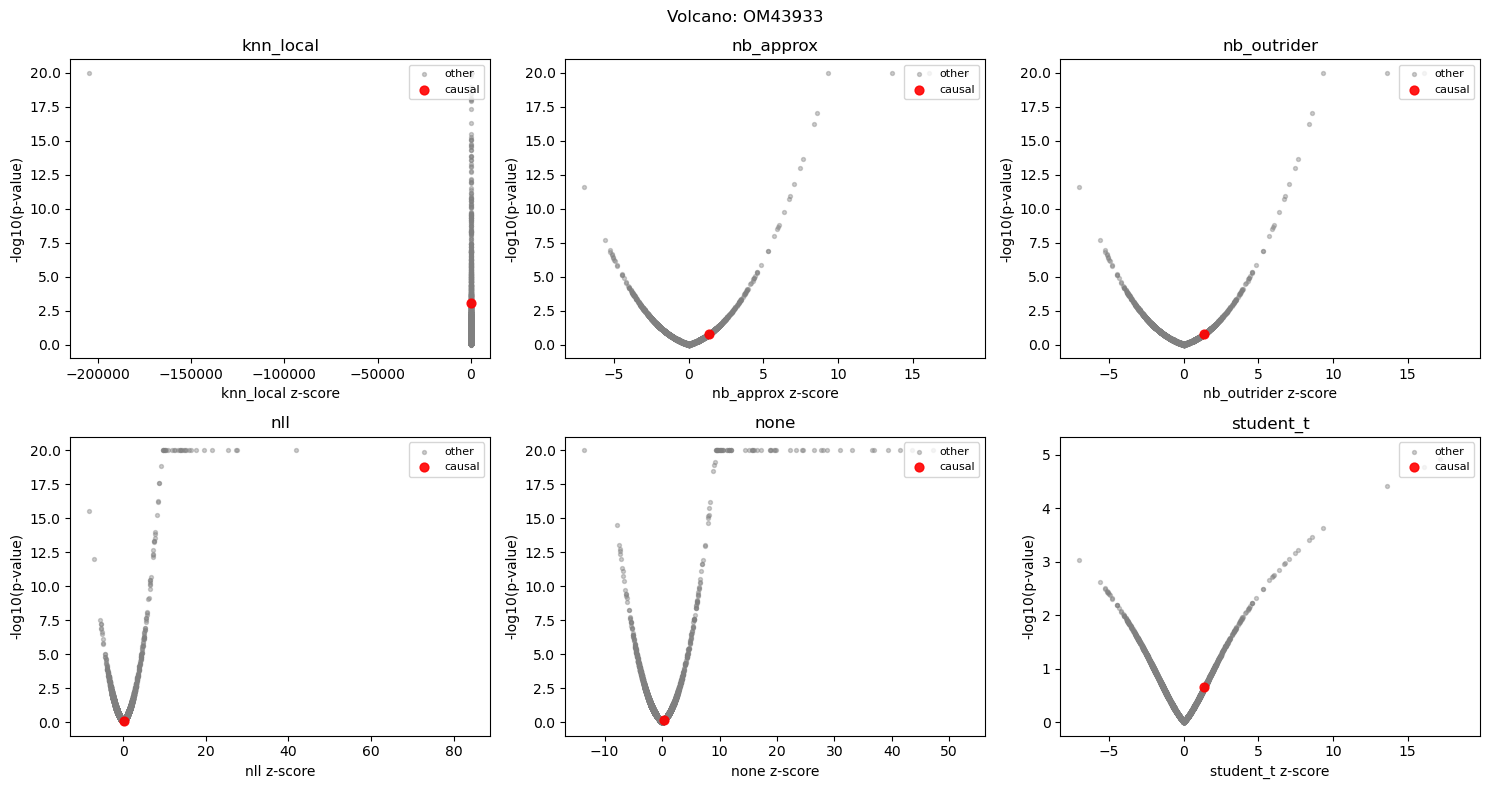

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM87369.png


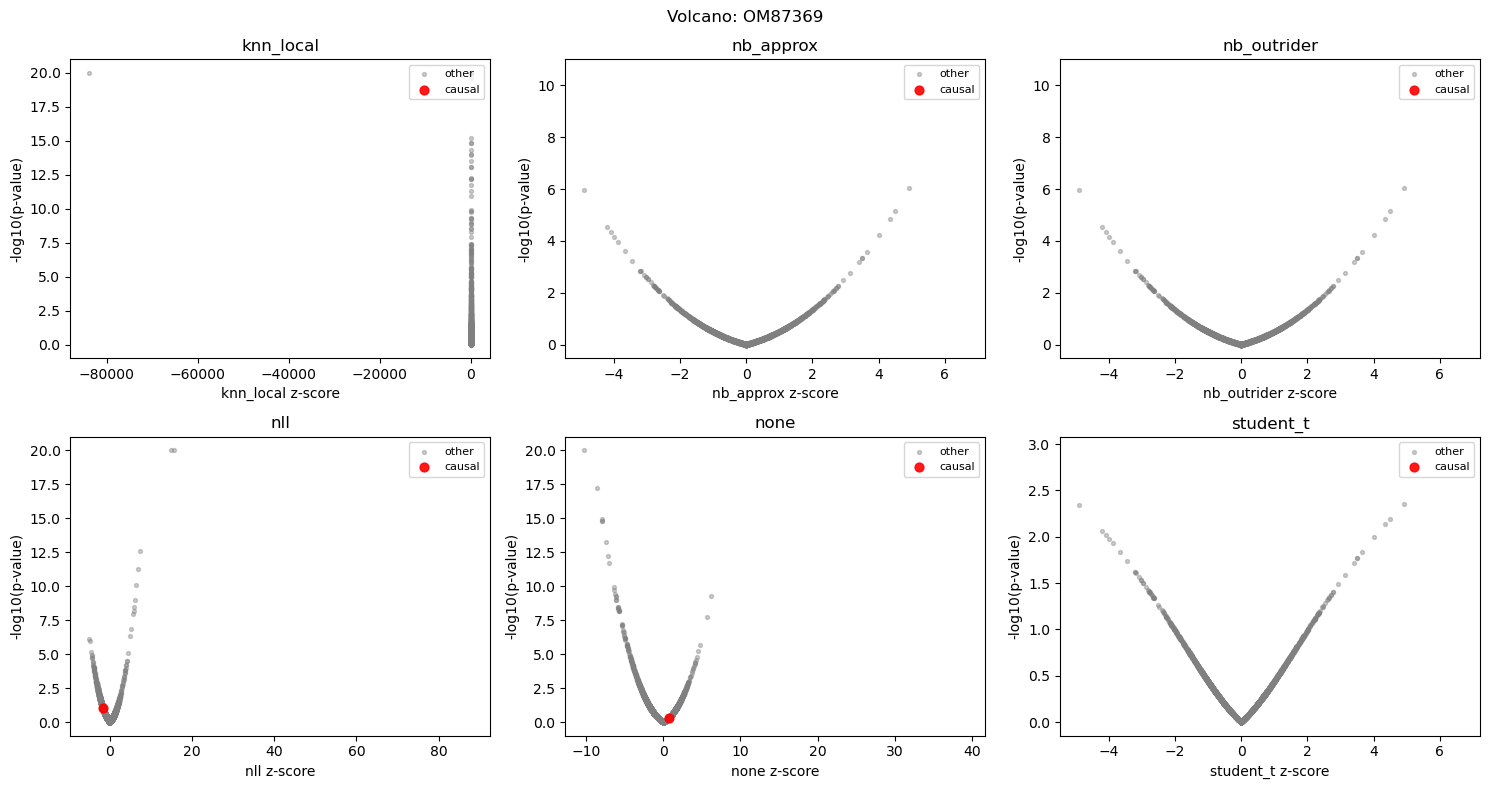

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM91786.png


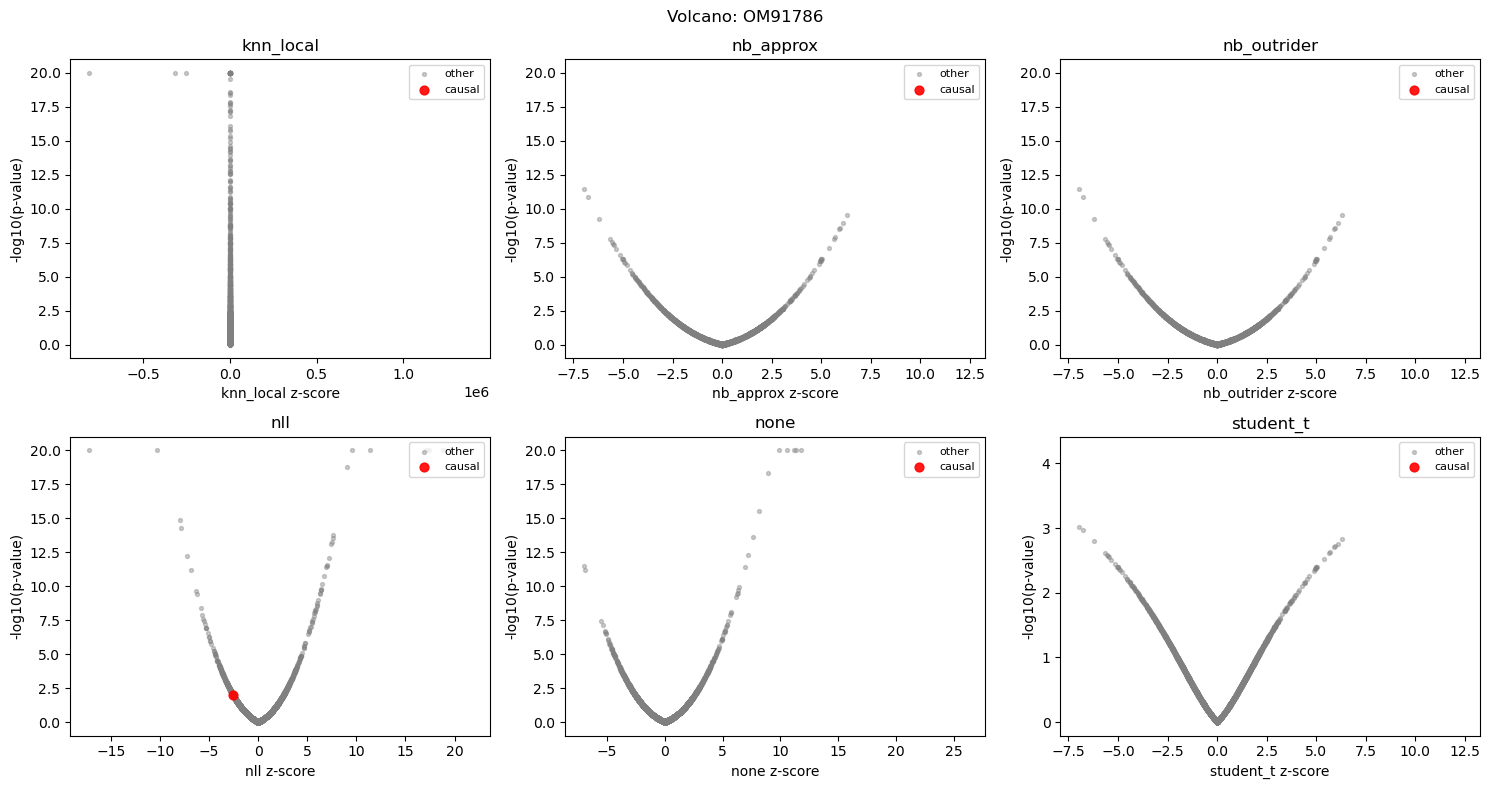

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM65708.png


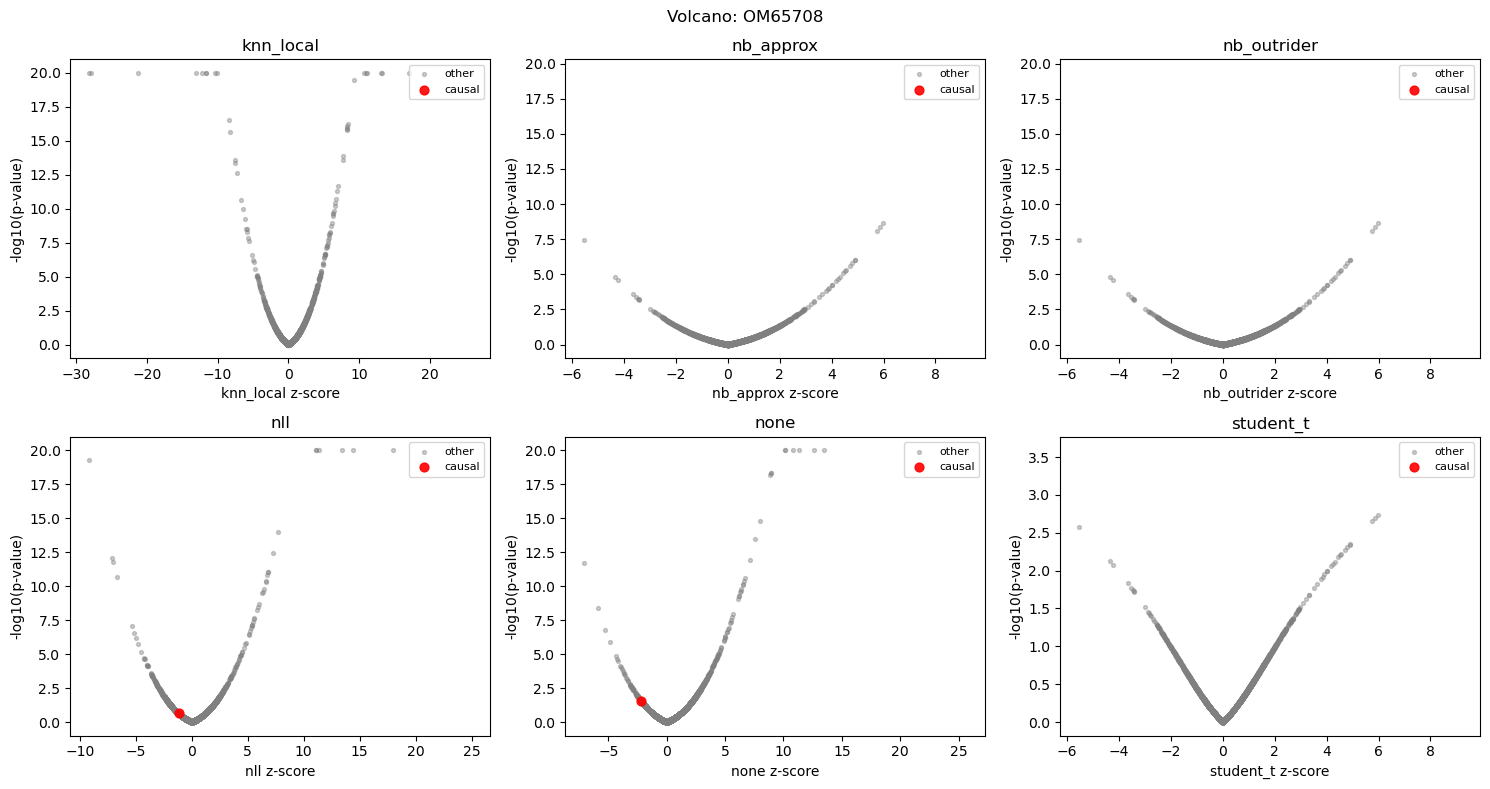

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM27390.png


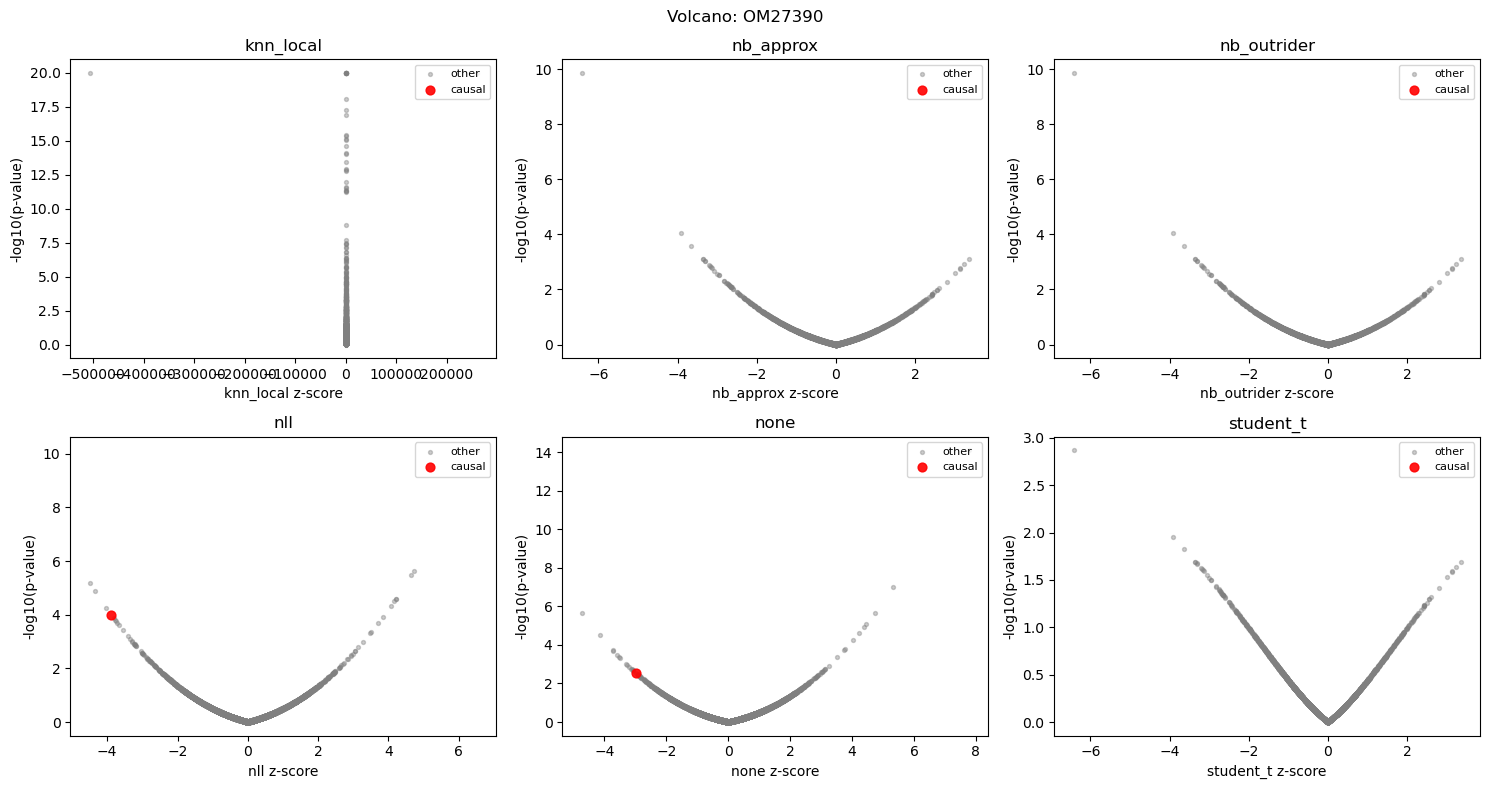

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/volcano_OM32691.png


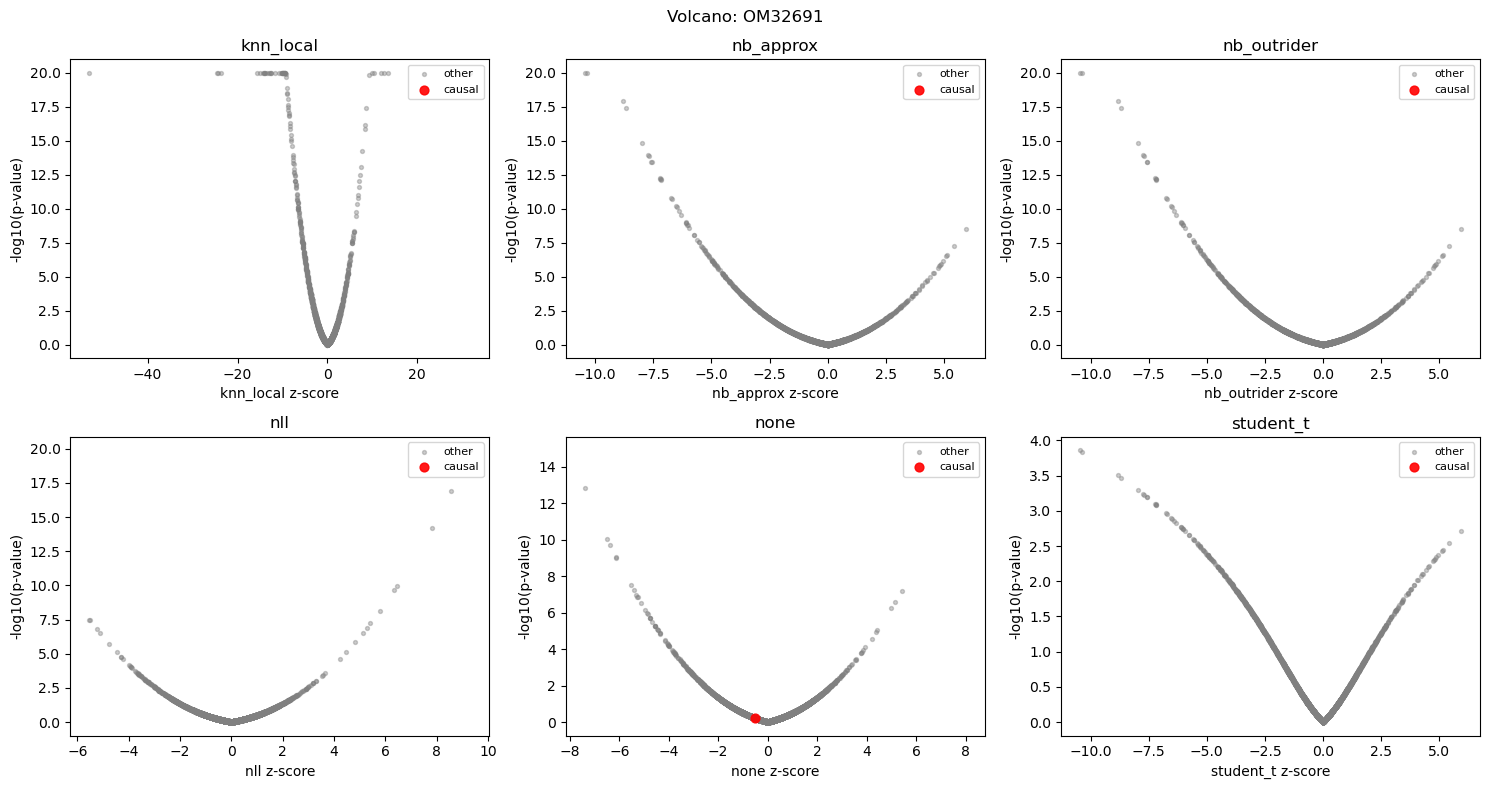

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_EPG5.png


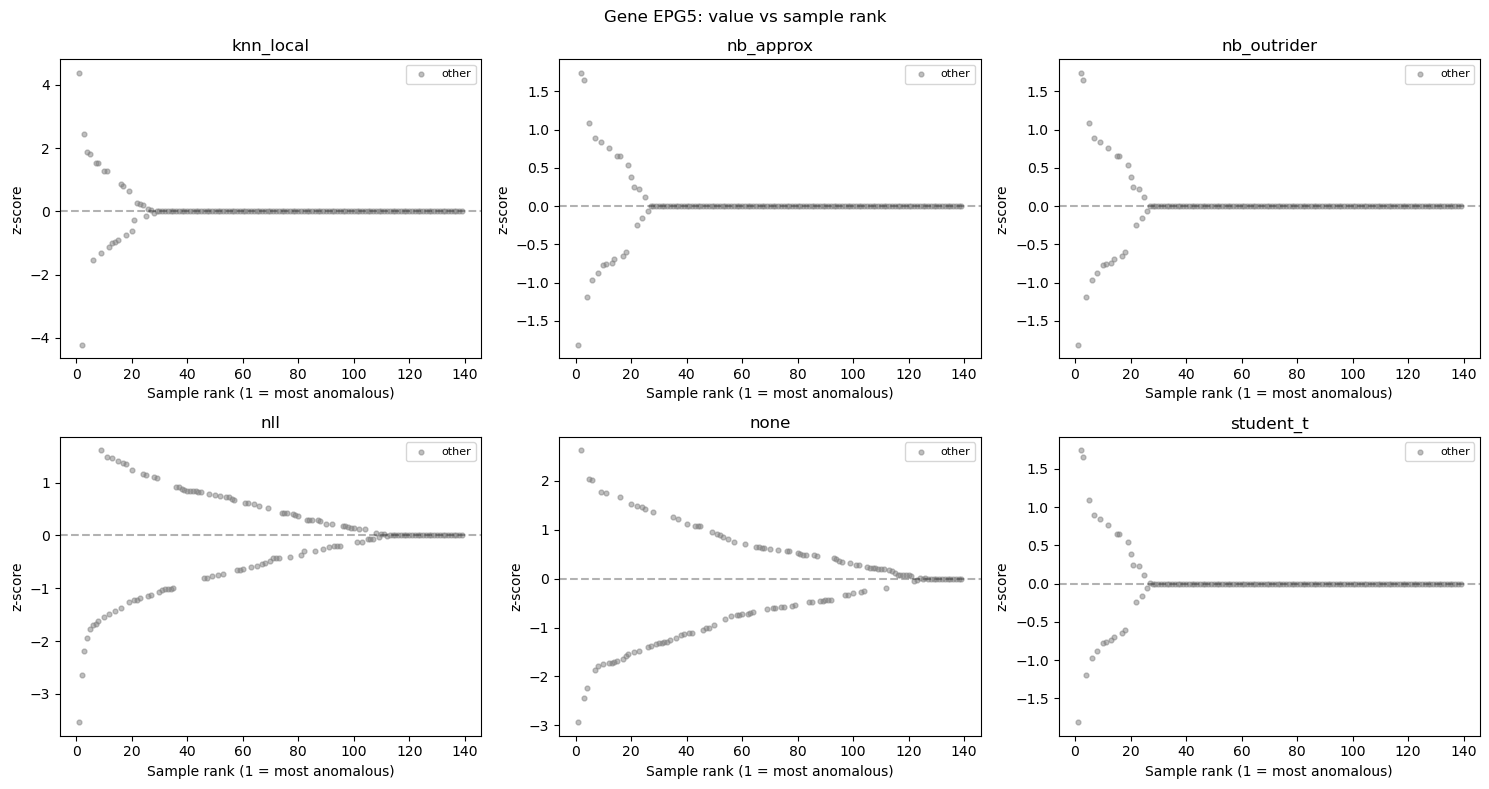

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_FDXR.png


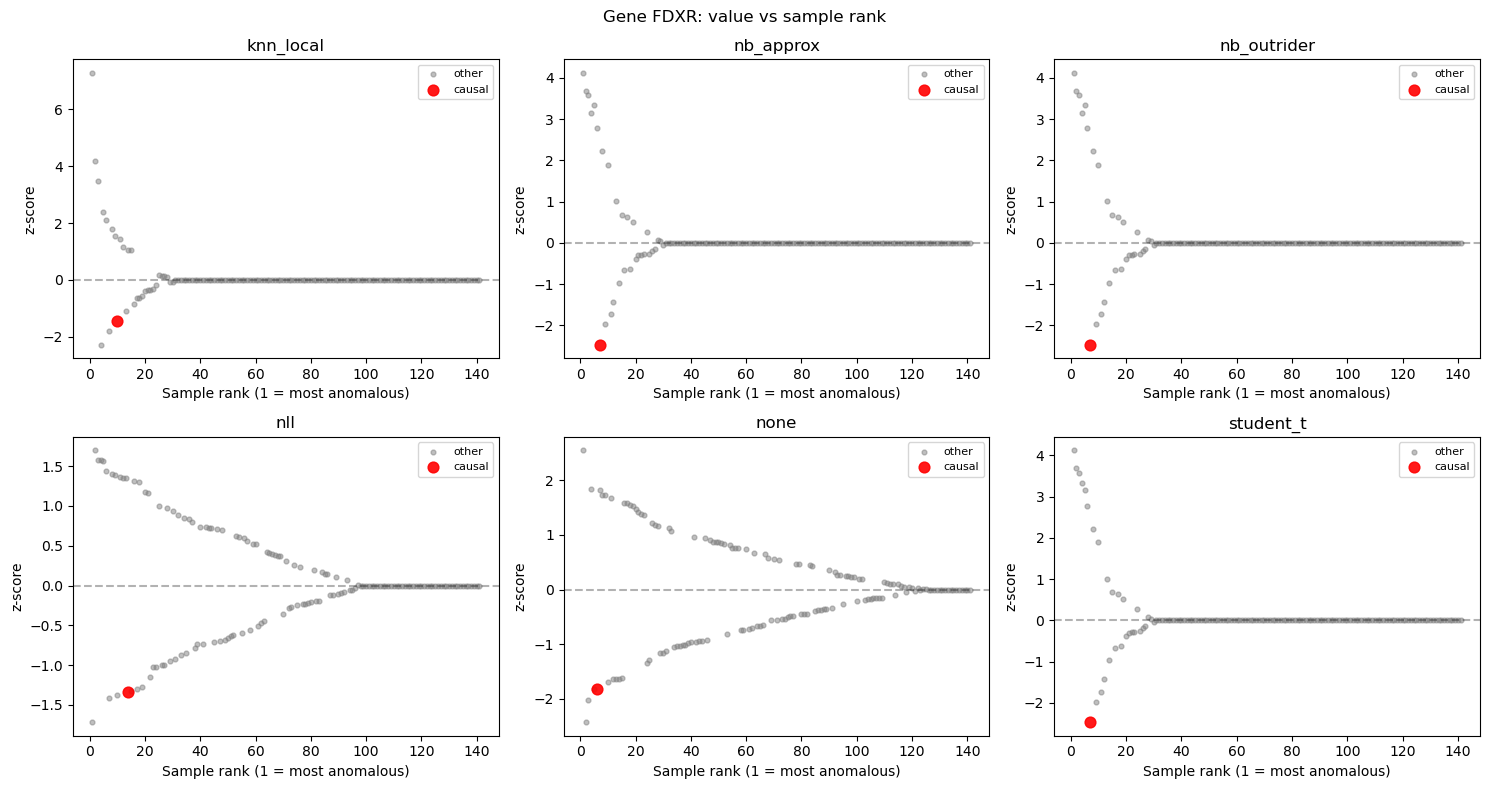

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_TIMMDC1.png


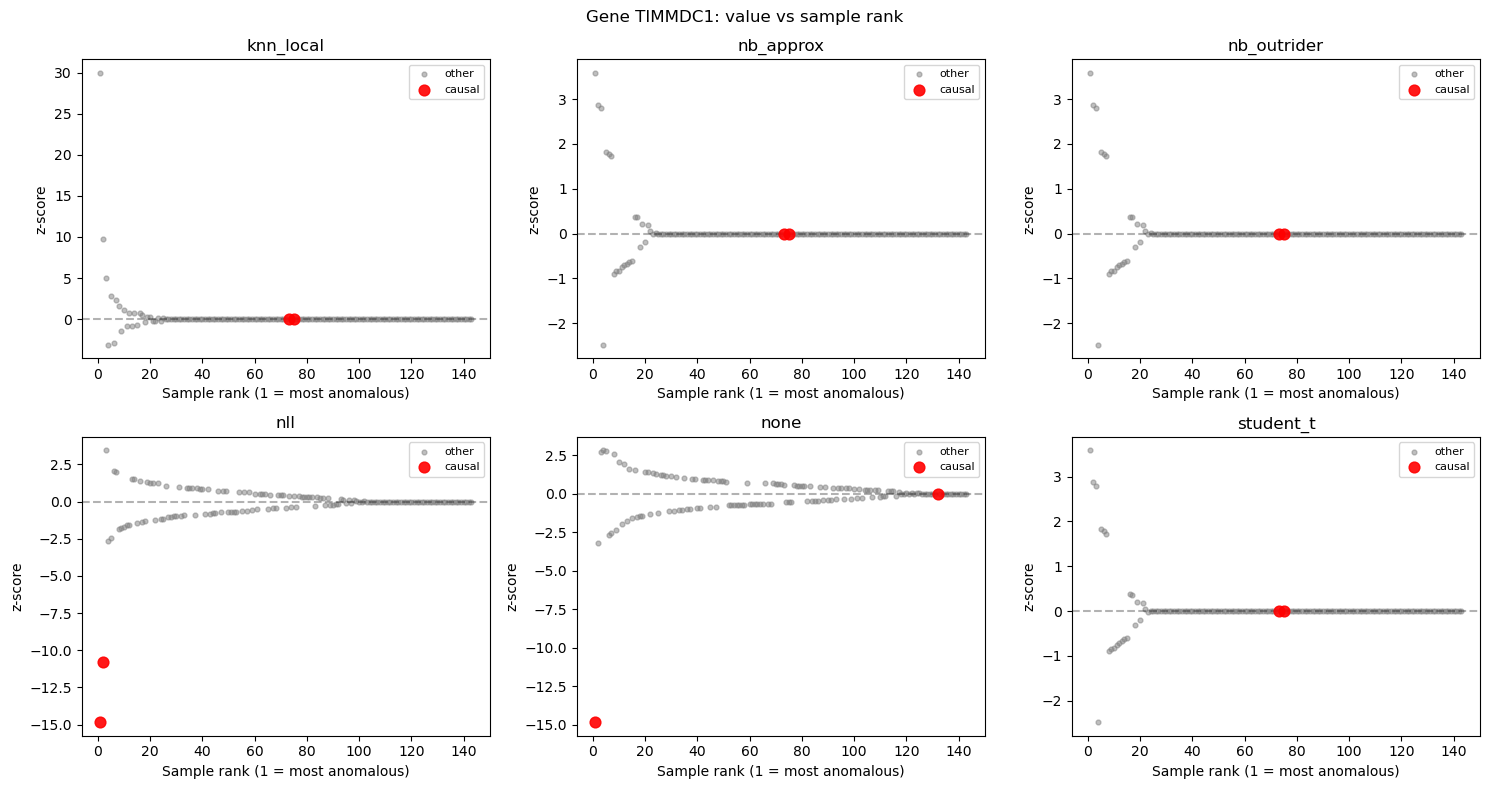

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_DNAJC30.png


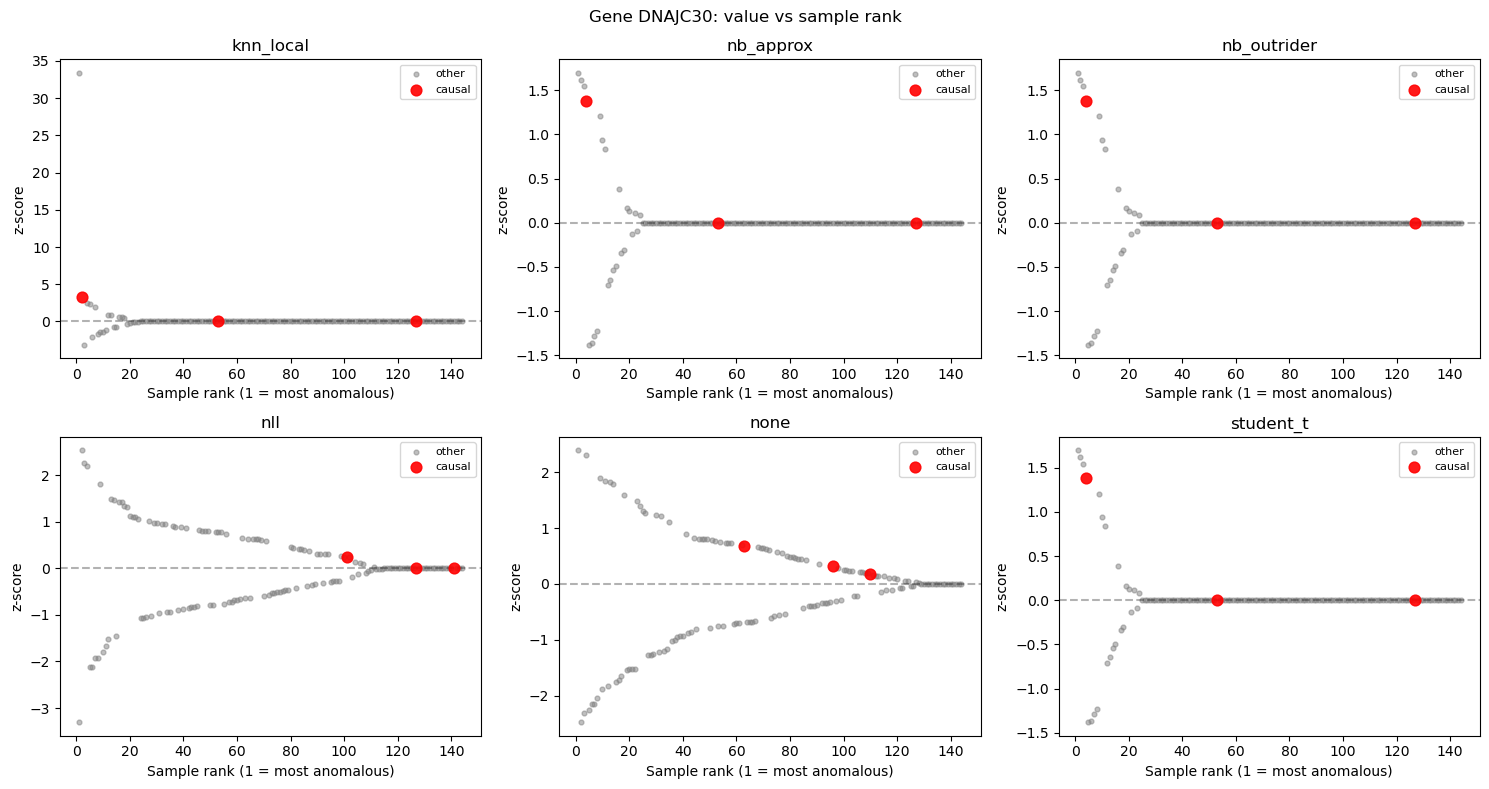

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_NDUFB11.png


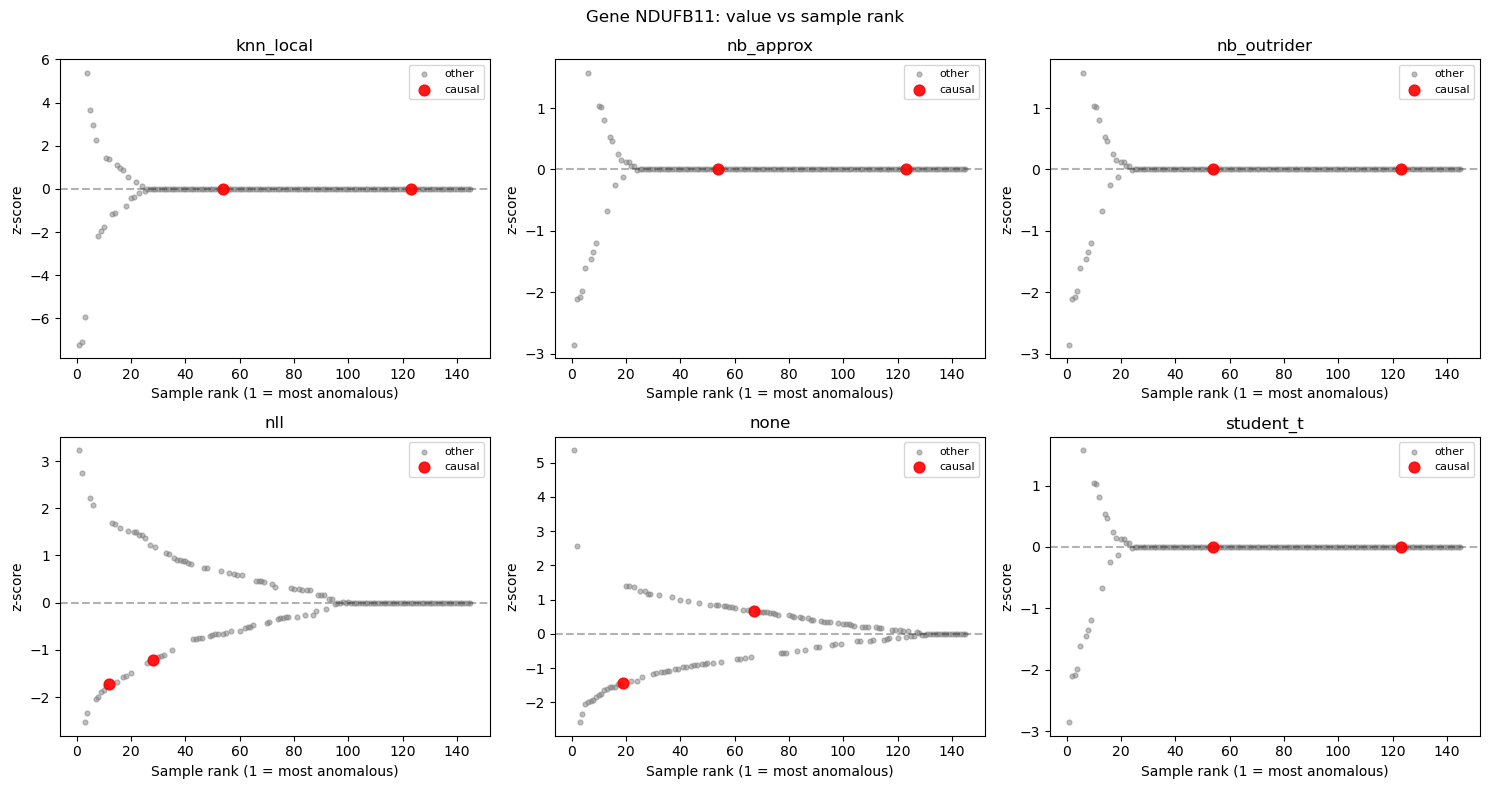

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_LIG3.png


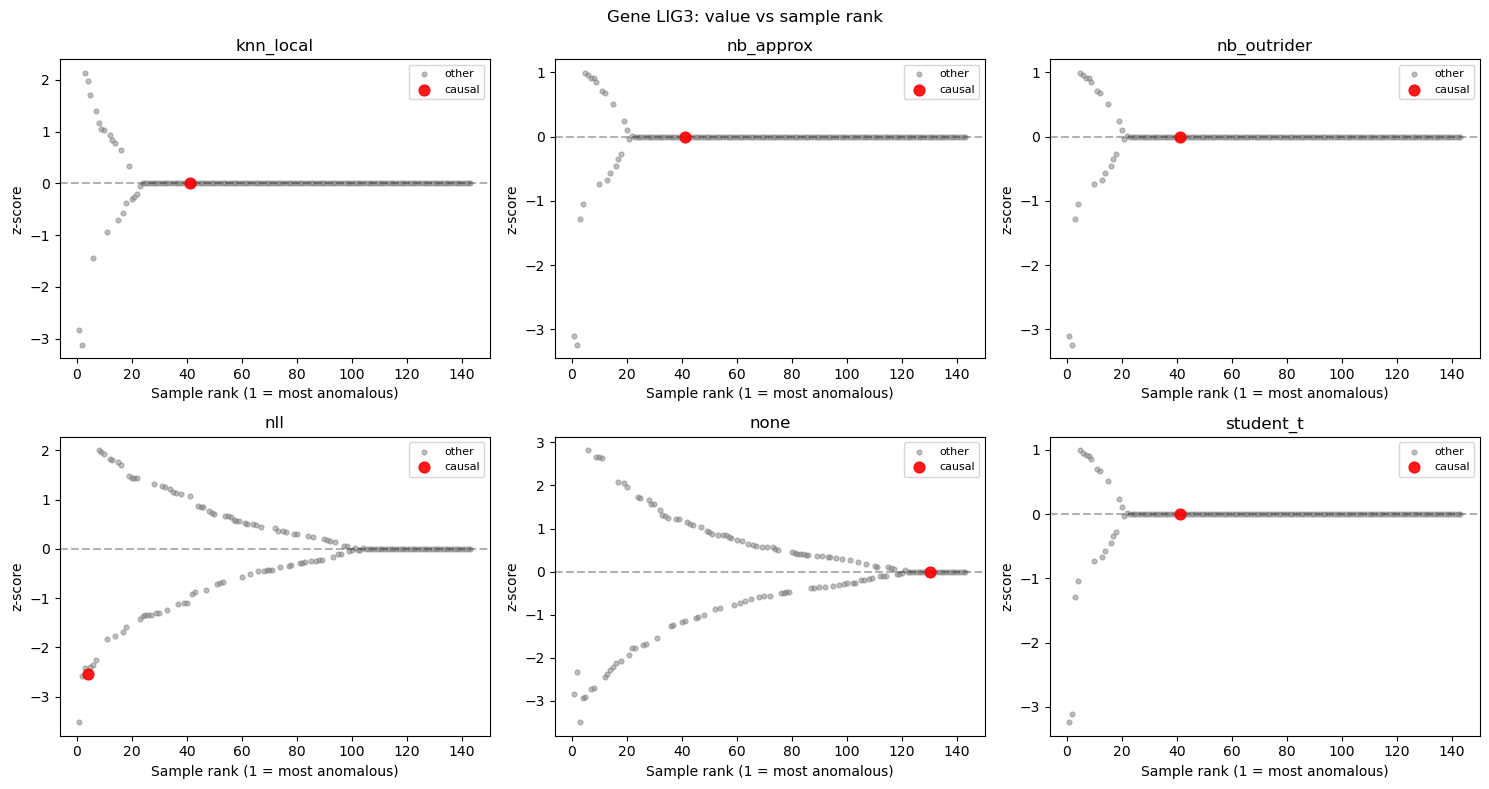

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_ACAD9.png


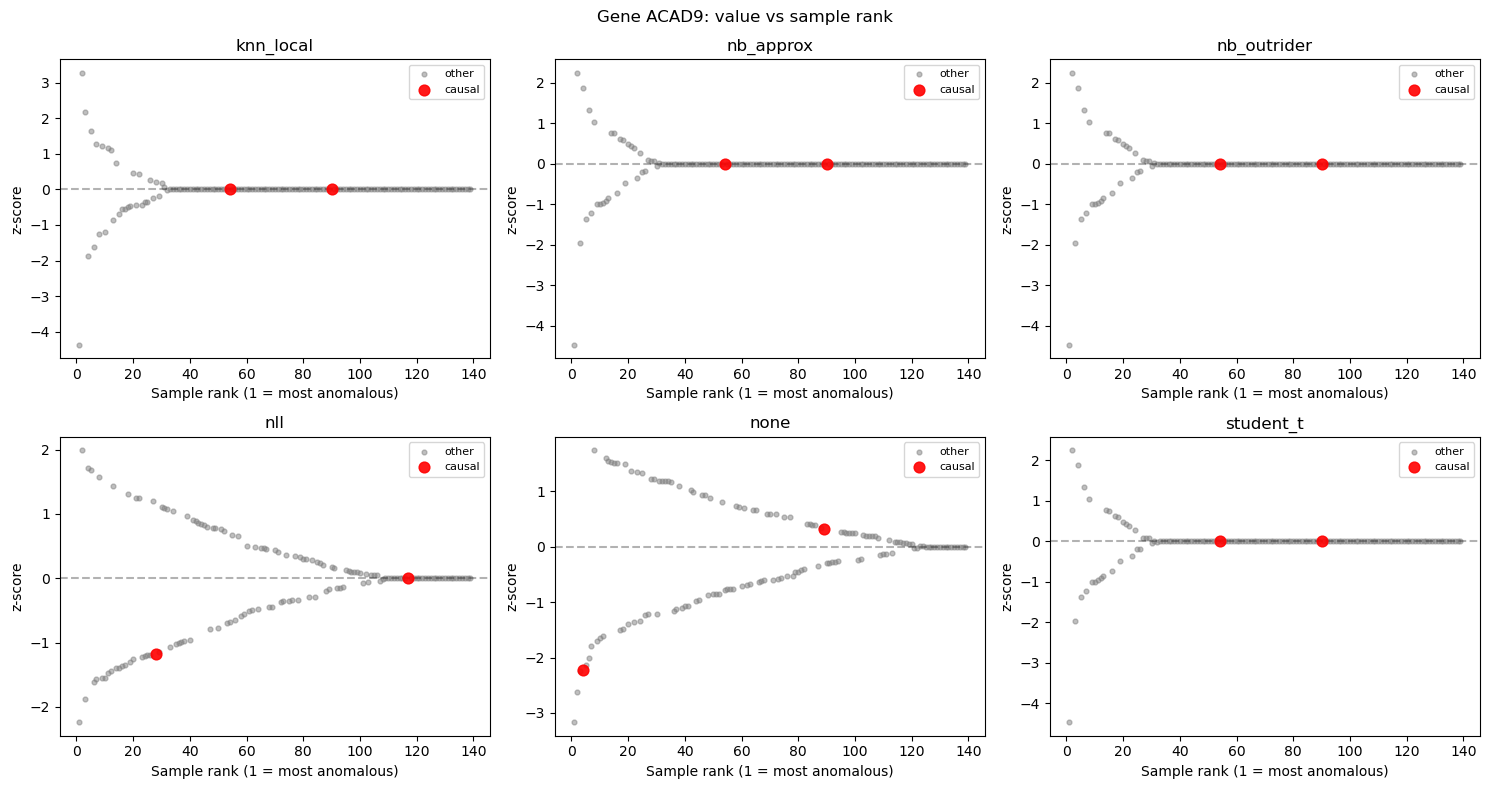

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_MORC2.png


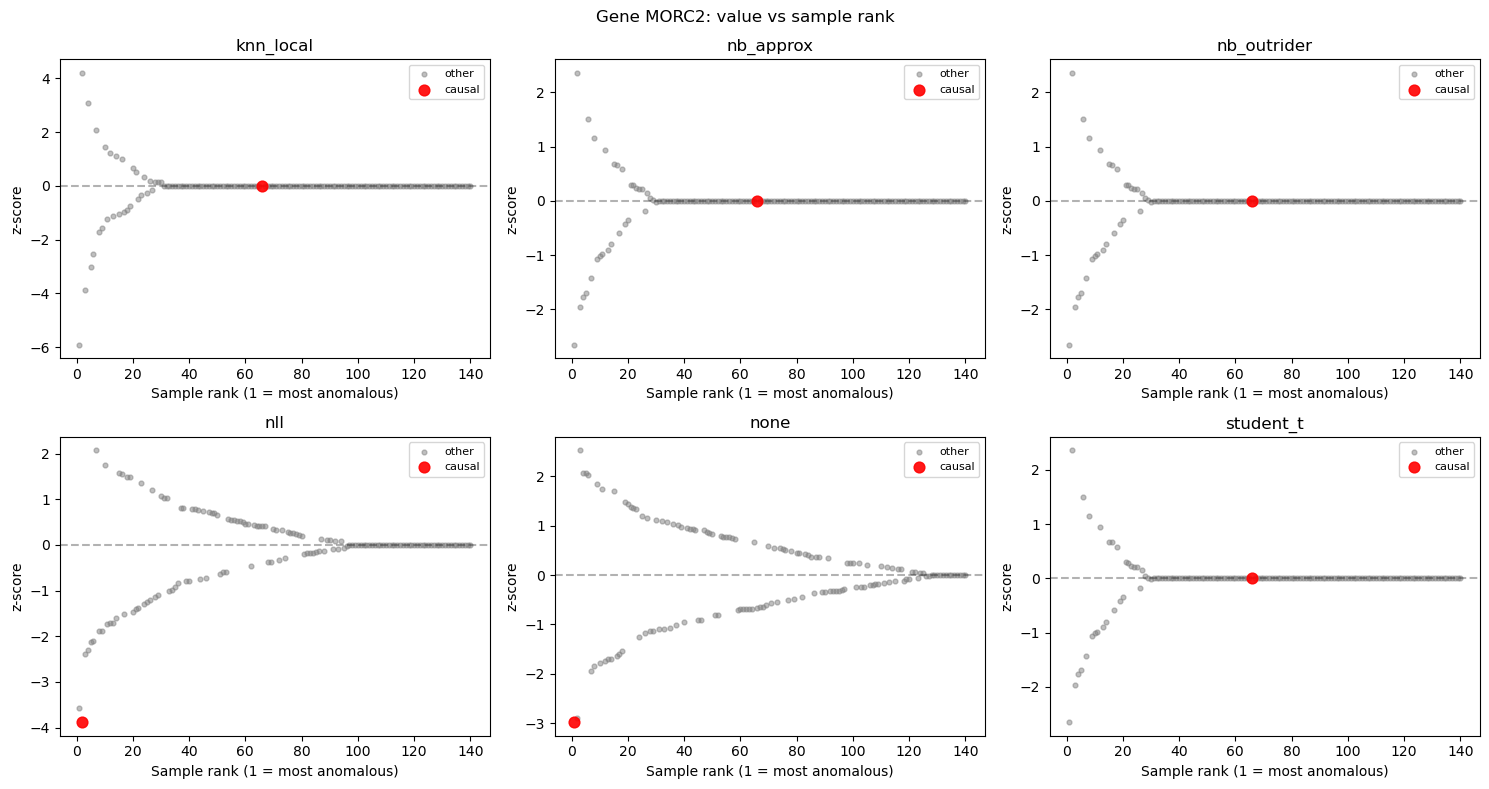

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_MT-ND5.png


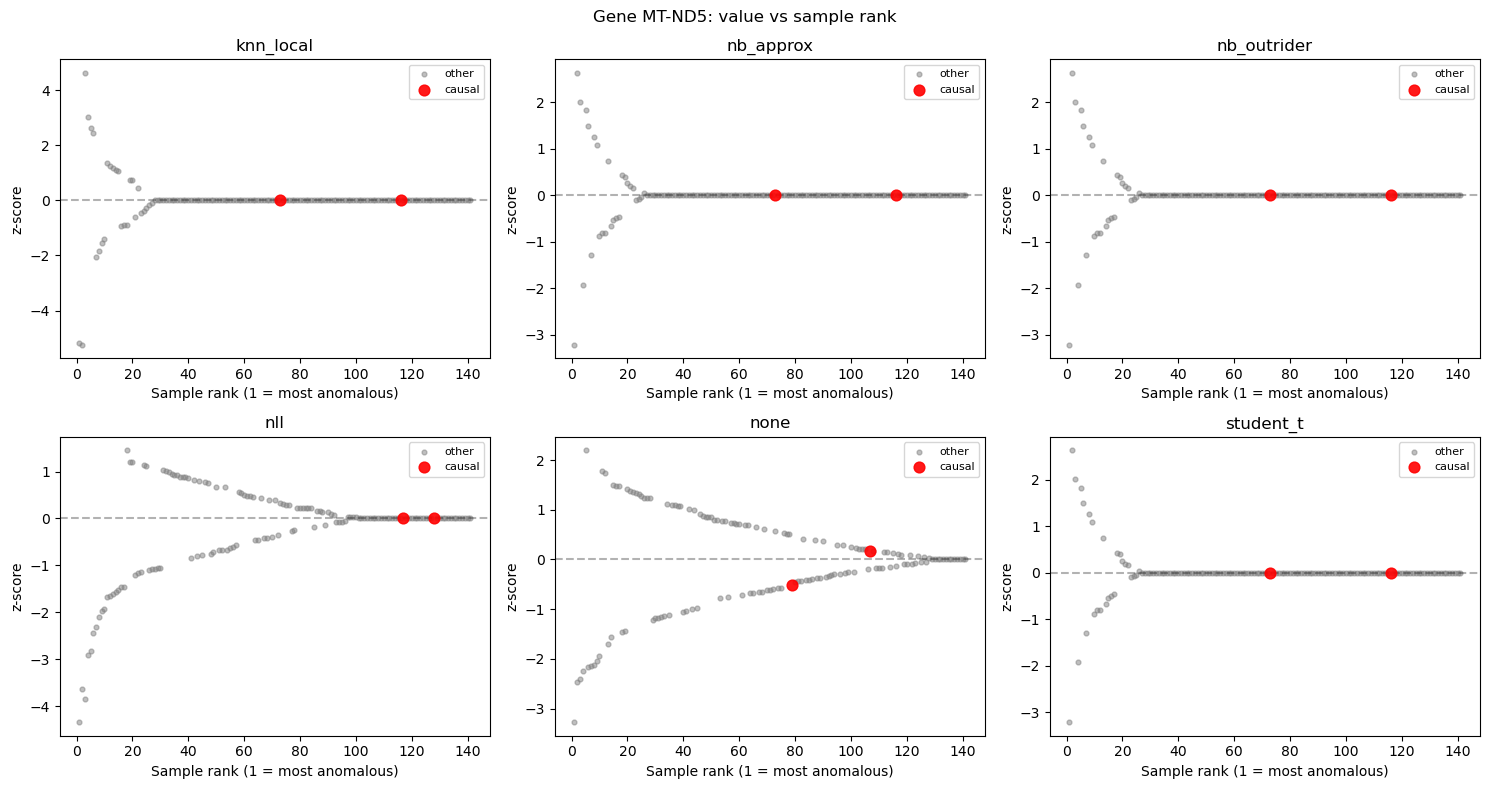

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_MRPL38.png


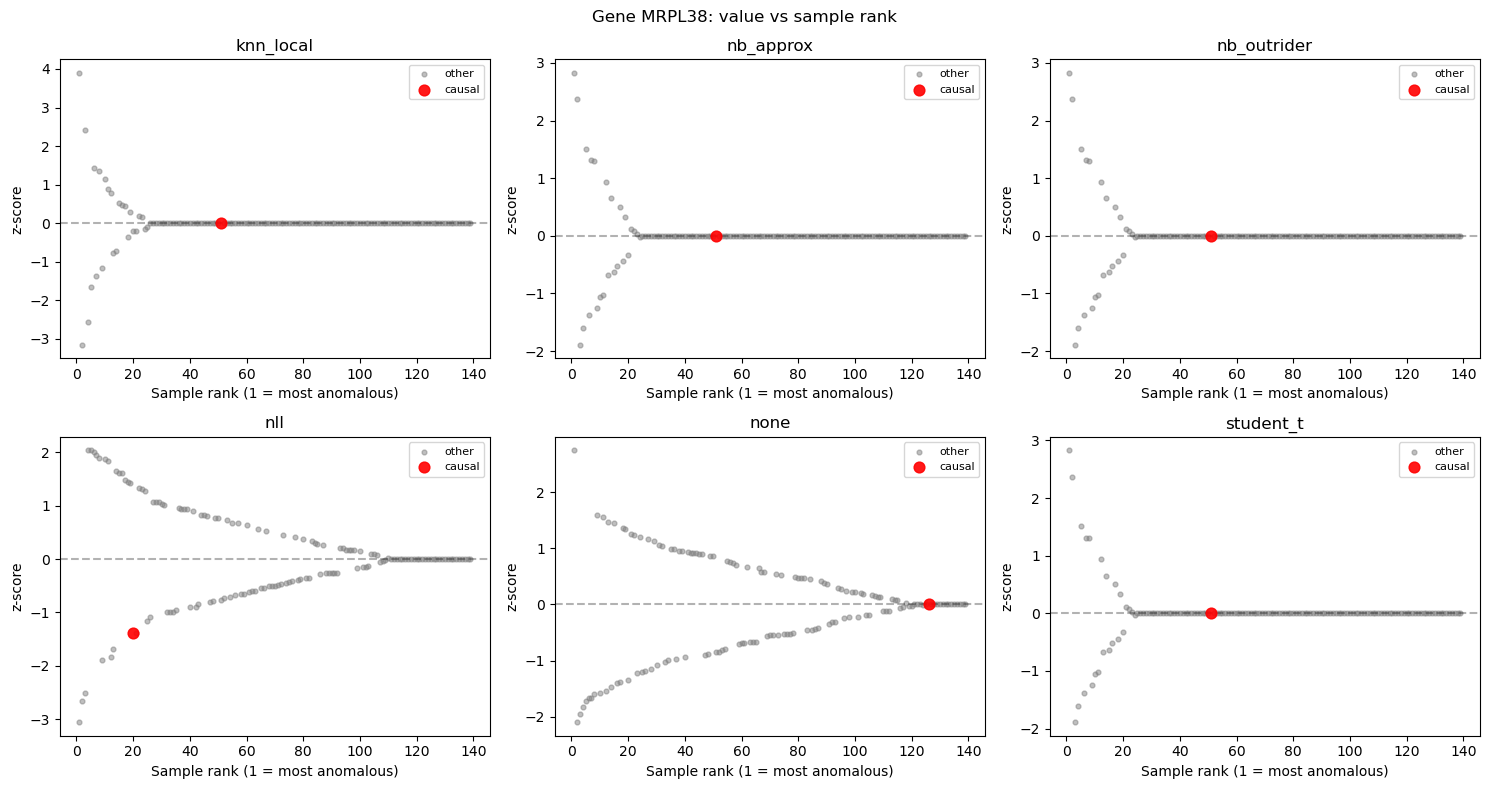

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_SSBP1.png


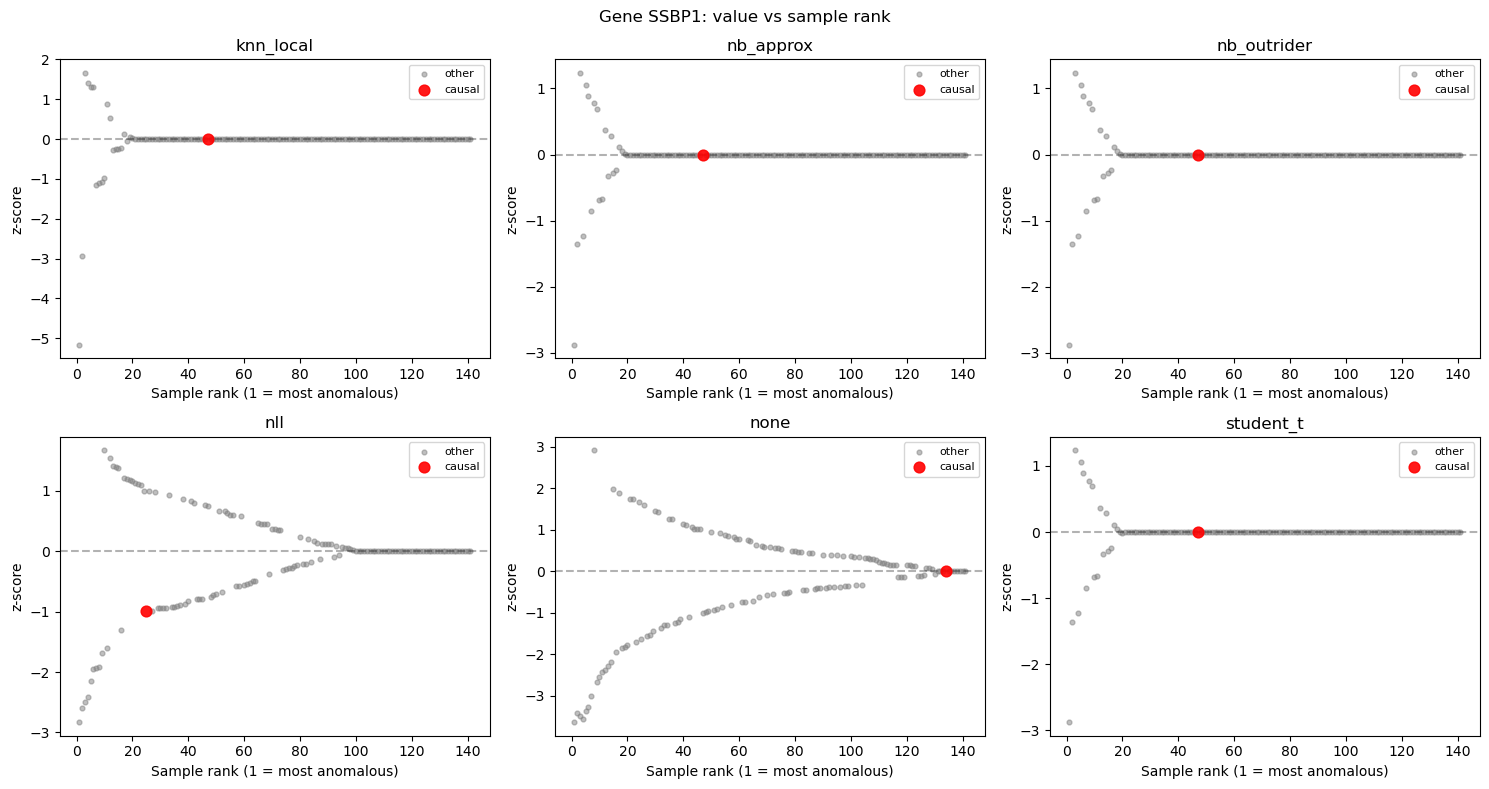

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_NFU1.png


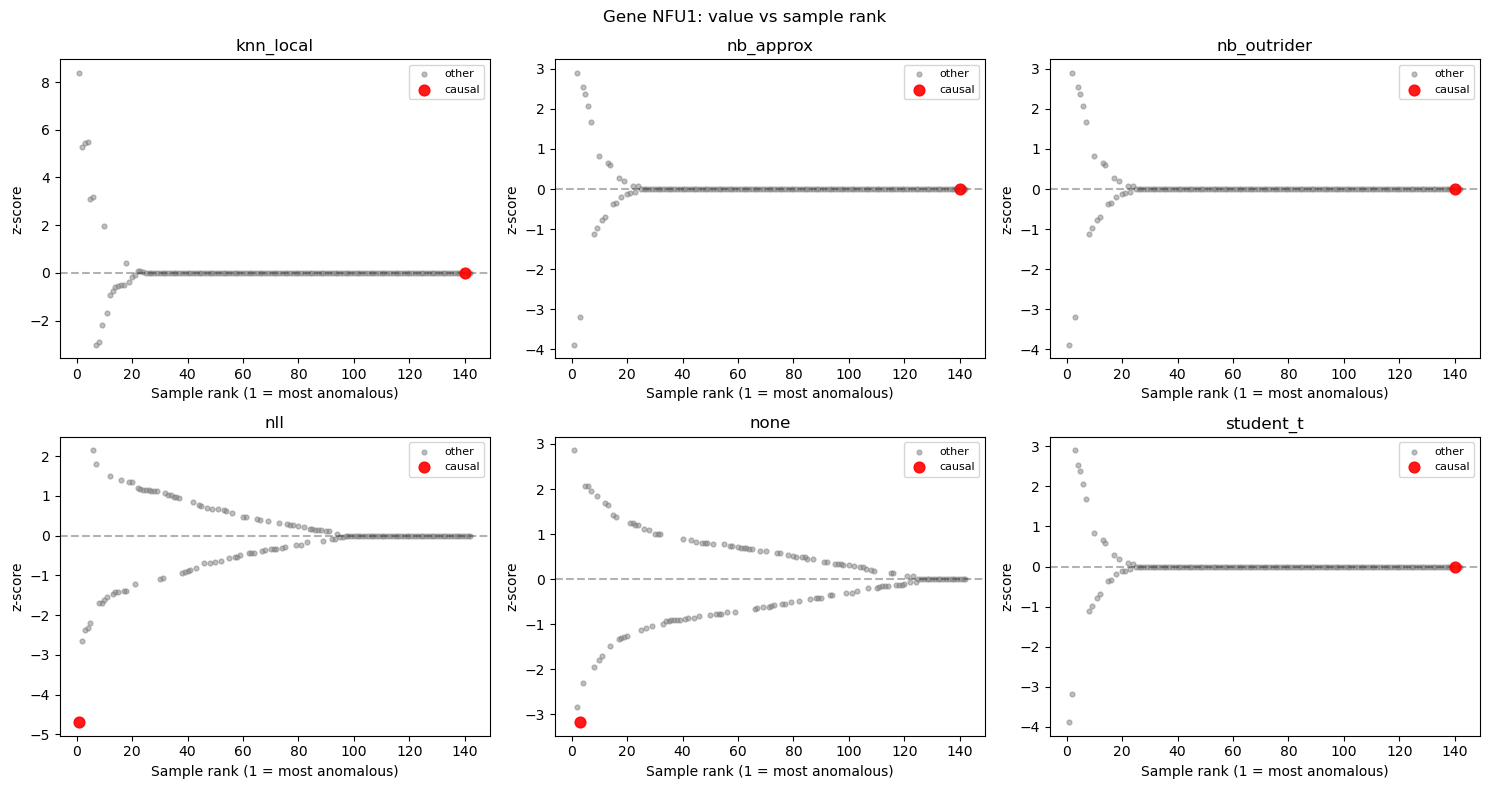

In [26]:
# Volcano plots (single-sample): run for several causal samples
VOLCANO_EXAMPLES = [
    ("OM06865", "EPG5"), ("OM23417", "FDXR"), ("OM38813", "TIMMDC1"), ("OM43933", "DNAJC30"),
    ("OM87369", "NDUFB11"), ("OM91786", "LIG3"), ("OM65708", "ACAD9"), ("OM27390", "MORC2"), ("OM32691", "MT-ND5"),
]
for sid, causal in VOLCANO_EXAMPLES:
    if sid in df["SampleID"].values:
        plot_volcano_per_sample(df, sid, METHODS)
        plt.show()

# Gene rank plots (cohort): run for several causal genes
RANK_EXAMPLES = ["EPG5", "FDXR", "TIMMDC1", "DNAJC30", "NDUFB11", "LIG3", "ACAD9", "MORC2", "MT-ND5", "MRPL38", "SSBP1", "NFU1"]
for g in RANK_EXAMPLES:
    if g in df["Gene_Name"].values:
        plot_gene_value_vs_sample_rank(df, g, METHODS)
        plt.show()

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/gene_ranks_TIMMDC1.png


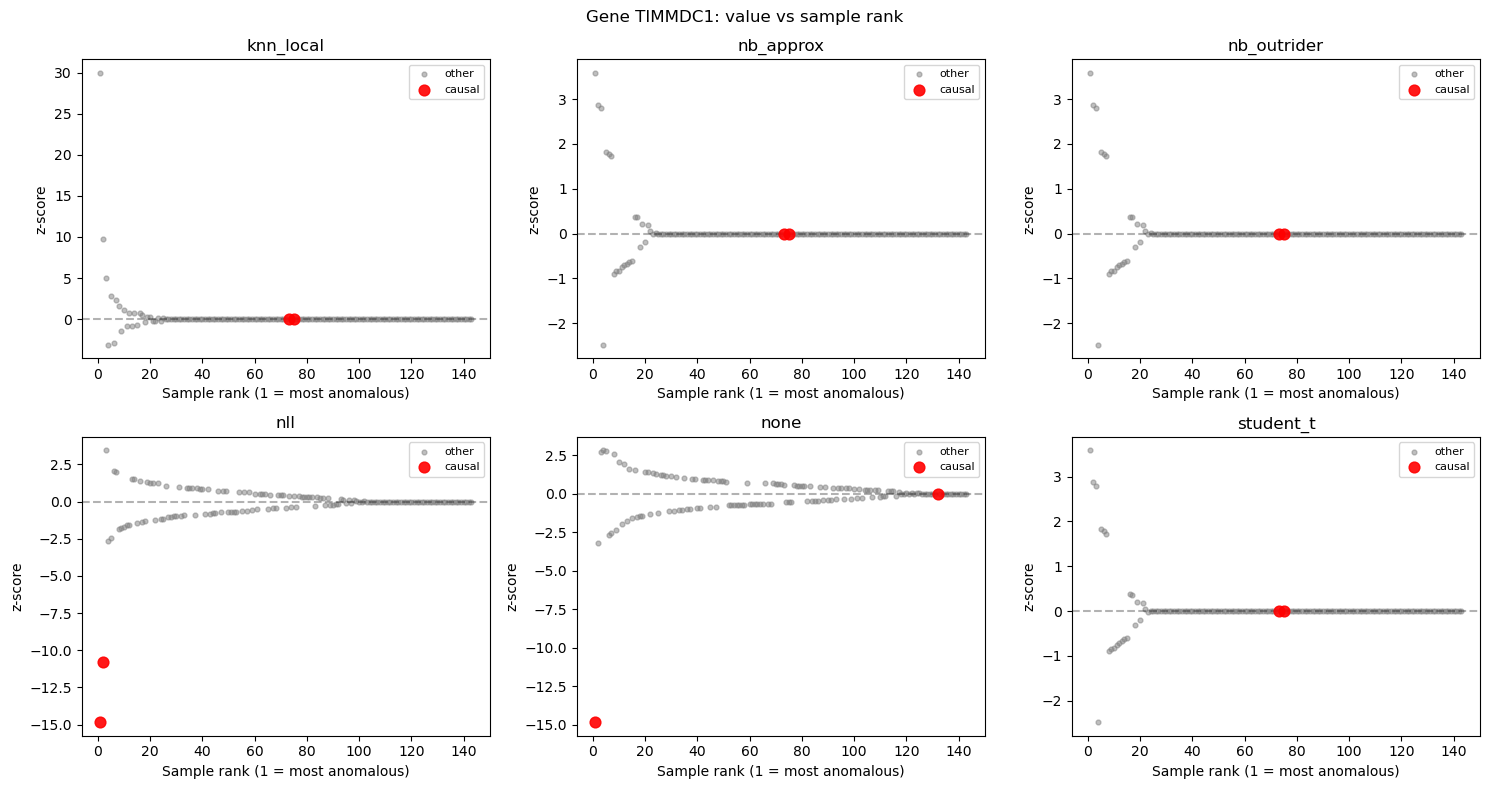

In [27]:
def plot_gene_value_vs_sample_rank(data: pd.DataFrame, gene_name: str, methods: list[str], value_col: str = "z_score"):
    """For a gene: rank samples by anomaly per method. X=sample rank (1=most anomalous), Y=z-score or residual. Returns fig for display."""
    sub = data[data["Gene_Name"] == gene_name].copy()
    if sub.empty:
        print(f"No data for gene {gene_name}")
        return None
    n = len(methods)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.ravel()
    for i, method in enumerate(methods):
        ax = axes[i]
        zcol = f"{method}_z_score"
        pcol = f"{method}_by_adj_p_value"
        mucol = f"{method}_expected_mu"
        if zcol not in sub.columns:
            ax.text(0.5, 0.5, f"{method}: no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(method)
            continue
        s = sub.copy()
        s["_abs_z"] = s[zcol].fillna(0).abs()
        s = s.sort_values([pcol, "_abs_z"], ascending=[True, False], na_position="last")
        s["sample_rank"] = range(1, len(s) + 1)
        if value_col == "residual" and mucol in s.columns:
            s["_val"] = s["observed_log1p_tpm"] - s[mucol]
        else:
            s["_val"] = s[zcol].fillna(0)
        causal = s["is_known_causal_gene"].fillna(False).values
        ax.scatter(s["sample_rank"][~causal], s["_val"][~causal], alpha=0.5, s=12, c="gray", label="other")
        if causal.any():
            ax.scatter(s["sample_rank"][causal], s["_val"][causal], alpha=0.9, s=60, c="red", label="causal", zorder=5)
        ax.axhline(0, color="k", linestyle="--", alpha=0.3)
        ax.set_xlabel("Sample rank (1 = most anomalous)")
        ax.set_ylabel("z-score" if value_col != "residual" else "residual")
        ax.set_title(method)
        ax.legend(loc="upper right", fontsize=8)
    for j in range(len(methods), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"Gene {gene_name}: value vs sample rank", fontsize=12)
    fig.tight_layout()
    out_path = FIGURES_DIR / f"gene_ranks_{gene_name}.png"
    fig.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")
    return fig

fig = plot_gene_value_vs_sample_rank(df, gene_name, METHODS, value_col="z_score")
if fig is not None:
    plt.show()

## 5. Recall of Causal Genes (cohort)

**Scope:** Full cohort. Recall@K and rank of causal gene per method. Ground truth: samples with known_causal_gene; match Gene_Name == known_causal_gene.

,method,recall@1,recall@5,recall@10,recall@50,median_rank
0,knn_local,0.0000,0.0000,0.0000,0.0000,7709.0
1,nb_approx,0.0185,0.0185,0.0185,0.0556,7709.0
2,nb_outrider,0.0185,0.0185,0.0185,0.0556,7709.0
3,nll,0.0000,0.0000,0.0370,0.0926,4633.0
4,none,0.0000,0.0000,0.0000,0.0741,7208.0
5,student_t,0.0185,0.0185,0.0185,0.0556,7709.0


/var/folders/bz/9_bvpqk57rq3x_63_gjfshjh0000gn/T/ipykernel_74970/2746479150.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(valid, labels=recall_df["method"])


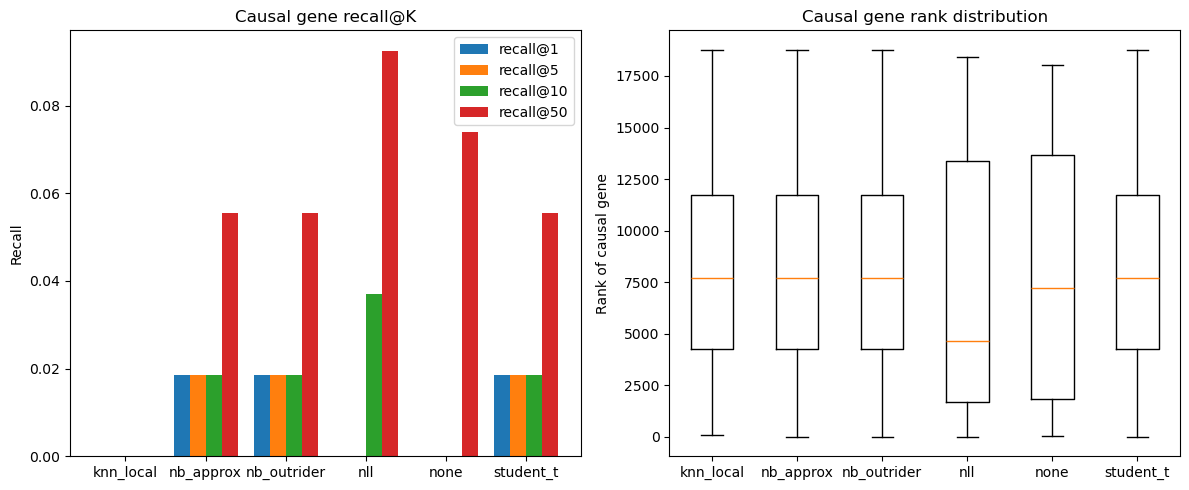

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/recall_causal.png


In [28]:
def compute_causal_recall(data: pd.DataFrame, methods: list[str], k_values: list[int] = [1, 5, 10, 50]) -> pd.DataFrame:
    """Compute recall@K and causal gene rank per method."""
    causal_samples = data.dropna(subset=["known_causal_gene"]).groupby("SampleID").agg({"known_causal_gene": "first"}).reset_index()
    if causal_samples.empty:
        return pd.DataFrame()
    n_causal = len(causal_samples)
    rows = []
    for method in methods:
        pcol = f"{method}_by_adj_p_value"
        zcol = f"{method}_z_score"
        if pcol not in data.columns:
            continue
        ranks = []
        recall_at = {k: 0 for k in k_values}
        for _, row in causal_samples.iterrows():
            sid = row["SampleID"]
            causal_gene = row["known_causal_gene"]
            sample_df = data[data["SampleID"] == sid].copy()
            sample_df["_z"] = sample_df[zcol].fillna(0).abs()
            sample_df = sample_df.sort_values([pcol, "_z"], ascending=[True, False])
            sample_df["rank"] = range(1, len(sample_df) + 1)
            hit = sample_df[sample_df["Gene_Name"] == causal_gene]
            r = int(hit["rank"].iloc[0]) if len(hit) > 0 else np.nan
            ranks.append(r)
            for k in k_values:
                if not np.isnan(r) and r <= k:
                    recall_at[k] += 1
        rows.append({
            "method": method,
            **{f"recall@{k}": recall_at[k] / n_causal for k in k_values},
            "median_rank": np.nanmedian(ranks),
            "ranks": ranks,
        })
    return pd.DataFrame(rows)

recall_df = compute_causal_recall(df, METHODS)
if not recall_df.empty:
    display(recall_df[["method", "recall@1", "recall@5", "recall@10", "recall@50", "median_rank"]].round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    k_cols = [c for c in recall_df.columns if c.startswith("recall@")]
    x = np.arange(len(recall_df))
    w = 0.2
    for i, kc in enumerate(k_cols):
        ax.bar(x + i * w, recall_df[kc], width=w, label=kc)
    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(recall_df["method"])
    ax.set_ylabel("Recall")
    ax.set_title("Causal gene recall@K")
    ax.legend()

    ax = axes[1]
    valid = [np.array(r)[np.isfinite(np.array(r))] for r in recall_df["ranks"]]
    if any(len(v) > 0 for v in valid):
        ax.boxplot(valid, labels=recall_df["method"])
    ax.set_ylabel("Rank of causal gene")
    ax.set_title("Causal gene rank distribution")
    fig.tight_layout()
    out_path = FIGURES_DIR / "recall_causal.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved {out_path}")

## 6. QQ Plots

Pool raw_p_value per method; QQ vs Uniform(0,1). Uses bulkformer_dx.benchmark.plots.plot_pvalue_qq.

/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/benchmark/plots.py:225: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/benchmark/plots.py:226: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(output_path, dpi=150)


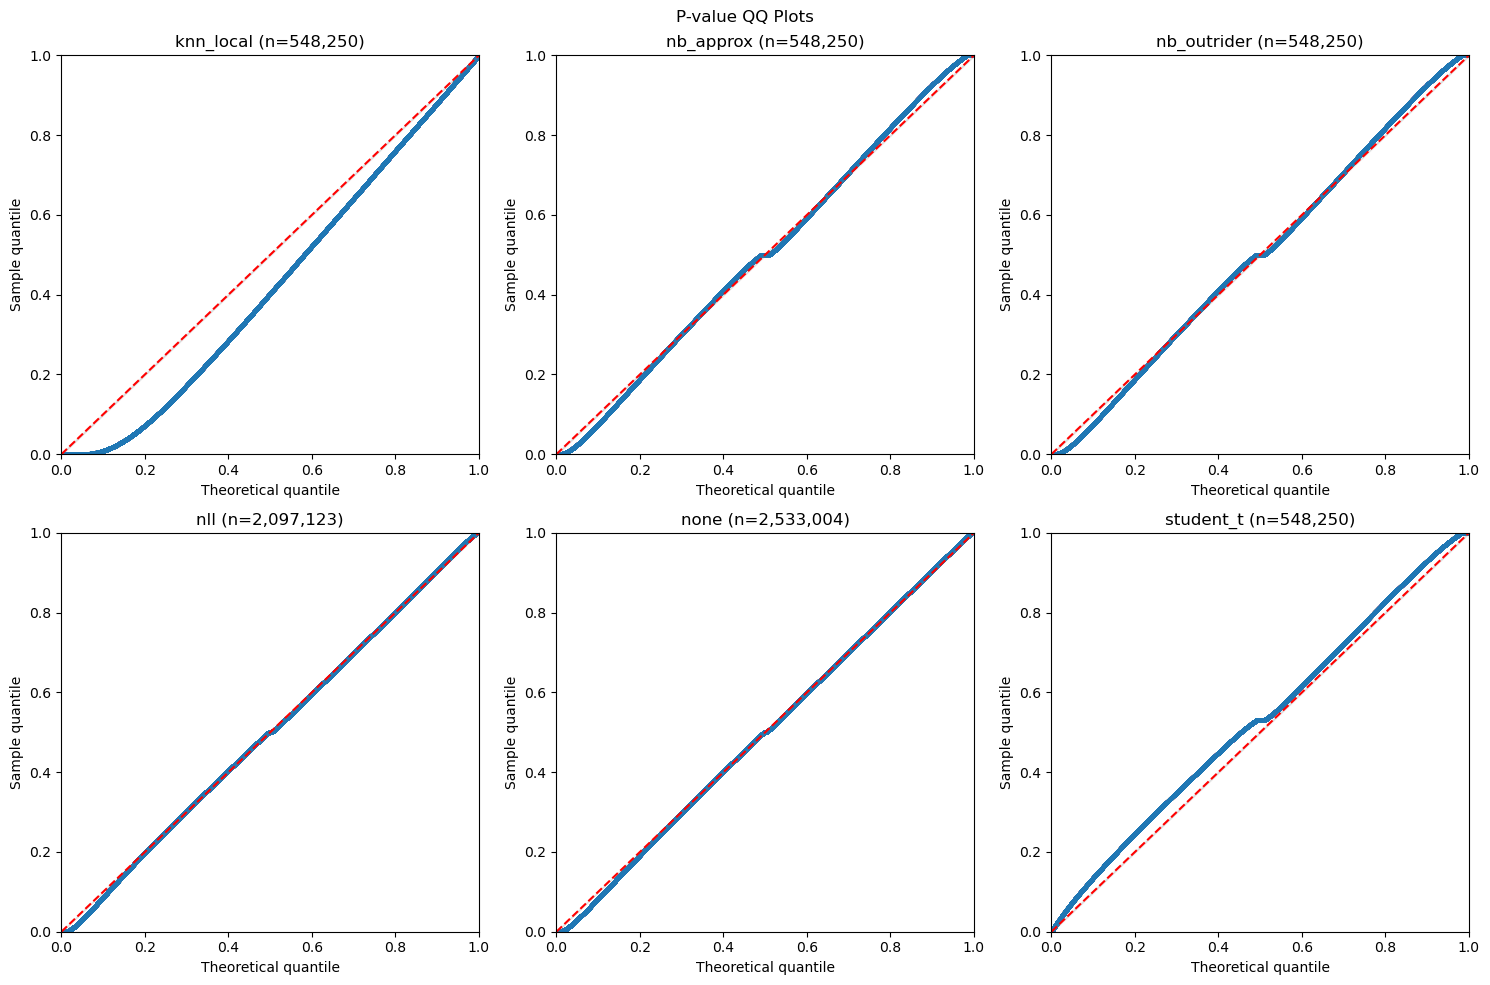

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/qq_all_methods.png


In [29]:
import sys
sys.path.insert(0, str(ROOT))
from bulkformer_dx.benchmark.plots import plot_pvalue_qq

# Per-method QQ plots (saved as qq_{method}.png)
for method in METHODS:
    pcol = f"{method}_raw_p_value"
    if pcol in df.columns:
        pvals = df[pcol].dropna().values
        pvals = pvals[np.isfinite(pvals) & (pvals >= 0) & (pvals <= 1)]
        if len(pvals) >= 2:
            plot_pvalue_qq(pvals, FIGURES_DIR / f"qq_{method}.png", ci_band=True)

n = len(METHODS)
cols = min(3, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
axes = axes.ravel()
for i, method in enumerate(METHODS):
    pcol = f"{method}_raw_p_value"
    if pcol not in df.columns:
        axes[i].text(0.5, 0.5, f"{method}: no data", ha="center", va="center", transform=axes[i].transAxes)
        axes[i].set_title(method)
        continue
    pvals = df[pcol].dropna().values
    pvals = pvals[np.isfinite(pvals) & (pvals >= 0) & (pvals <= 1)]
    if len(pvals) < 2:
        axes[i].text(0.5, 0.5, f"{method}: too few", ha="center", va="center", transform=axes[i].transAxes)
        axes[i].set_title(method)
        continue
    pvals = np.sort(pvals)
    n_p = len(pvals)
    theoretical = np.linspace(0, 1, n_p + 2)[1:-1]
    axes[i].scatter(theoretical, pvals, alpha=0.3, s=2)
    axes[i].plot([0, 1], [0, 1], "r--", label="Uniform(0,1)")
    if n_p >= 10:
        ks_eps = 1.36 / np.sqrt(n_p)
        lower = np.clip(theoretical - ks_eps, 0, 1)
        upper = np.clip(theoretical + ks_eps, 0, 1)
        axes[i].fill_between(theoretical, lower, upper, alpha=0.15, color="gray")
    axes[i].set_xlabel("Theoretical quantile")
    axes[i].set_ylabel("Sample quantile")
    axes[i].set_title(f"{method} (n={n_p:,})")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
for j in range(len(METHODS), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("P-value QQ Plots", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "qq_all_methods.png", dpi=150)
plt.show()
print(f"Saved {FIGURES_DIR / 'qq_all_methods.png'}")

## 7. Observed vs Predicted (per gene)

Scatter: observed_log1p_tpm vs expected_mu. 1:1 line; color by is_known_causal_gene when that gene is the causal one.

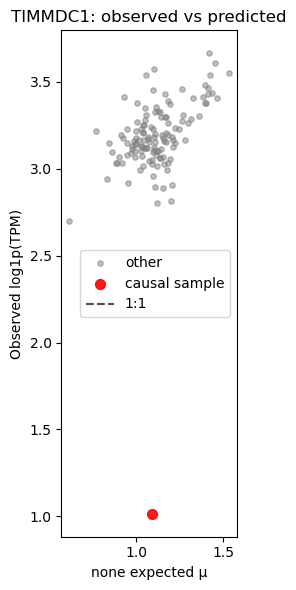

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/observed_vs_predicted_TIMMDC1.png


In [30]:
def plot_observed_vs_predicted(data: pd.DataFrame, gene_name: str, method: str = "none") -> None:
    sub = data[data["Gene_Name"] == gene_name].copy()
    if sub.empty:
        print(f"No data for gene {gene_name}")
        return
    mucol = f"{method}_expected_mu"
    if mucol not in sub.columns:
        print(f"No {mucol} column")
        return
    obs = sub["observed_log1p_tpm"].values
    exp = sub[mucol].values
    causal = sub["is_known_causal_gene"].fillna(False).values
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(exp[~causal], obs[~causal], alpha=0.5, s=15, c="gray", label="other")
    if causal.any():
        ax.scatter(exp[causal], obs[causal], alpha=0.9, s=50, c="red", label="causal sample", zorder=5)
    lims = [min(obs.min(), exp.min()), max(obs.max(), exp.max())]
    ax.plot(lims, lims, "k--", alpha=0.7, label="1:1")
    ax.set_xlabel(f"{method} expected μ")
    ax.set_ylabel("Observed log1p(TPM)")
    ax.set_title(f"{gene_name}: observed vs predicted")
    ax.legend()
    ax.set_aspect("equal")
    fig.tight_layout()
    out_path = FIGURES_DIR / f"observed_vs_predicted_{gene_name}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved {out_path}")

# Uses gene_name from interactive inputs above
if gene_name in df["Gene_Name"].values:
    plot_observed_vs_predicted(df, gene_name, "none")
else:
    gene_plot = df["Gene_Name"].dropna().iloc[0] if len(df) > 0 else ""
    if gene_plot:
        plot_observed_vs_predicted(df, gene_plot, "none")

## 8. Stratified / Variance vs Mean (optional)

Reuse plot_residual_variance_vs_mean and plot_stratified_pvalue_histograms from bulkformer_dx/benchmark/plots.py.

In [31]:
from bulkformer_dx.benchmark.plots import plot_residual_variance_vs_mean, plot_stratified_pvalue_histograms

# Aggregate per-gene: mean observed, variance of residuals (observed - expected) for one method
method = "none"
mucol = f"{method}_expected_mu"
if mucol in df.columns:
    work = df.copy()
    work["_residual"] = work["observed_log1p_tpm"] - work[mucol]
    gene_stats = work.groupby("GeneID").agg(
        mean_obs=("observed_log1p_tpm", "mean"),
        residual_var=("_residual", "var"),
    ).reset_index()
    gs = gene_stats.dropna(subset=["mean_obs", "residual_var"])
    gs = gs[(gs["residual_var"] > 0) & np.isfinite(gs["residual_var"])]
    gene_means = gs["mean_obs"].values
    gene_vars = gs["residual_var"].values
    if len(gene_means) > 2:
        plot_residual_variance_vs_mean(gene_means, gene_vars, FIGURES_DIR / "variance_vs_mean.png")
        print(f"Saved {FIGURES_DIR / 'variance_vs_mean.png'}")

# Stratified p-value histograms by expression bin
pcol = f"{method}_raw_p_value"
if pcol in df.columns:
    strat_df = df.copy()
    strat_df["_expr_bin"] = pd.qcut(strat_df["observed_log1p_tpm"].rank(method="first"), q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    strata = {b: strat_df[strat_df["_expr_bin"] == b][pcol].dropna().values for b in ["Q1", "Q2", "Q3", "Q4", "Q5"] if (strat_df["_expr_bin"] == b).any()}
    strata = {k: v for k, v in strata.items() if len(v) >= 2}
    if strata:
        plot_stratified_pvalue_histograms(strata, FIGURES_DIR / "stratified_histograms.png")
        print(f"Saved {FIGURES_DIR / 'stratified_histograms.png'}")

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/variance_vs_mean.png
Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/unified_outliers_browse/stratified_histograms.png


## 9. Method Comparison Summary

Table: Method | Mean outliers | Median outliers | Max outliers | Causal recall@1 | Causal recall@5

In [32]:
def method_comparison_table(data: pd.DataFrame, methods: list[str]) -> pd.DataFrame:
    rows = []
    recall_df = compute_causal_recall(data, methods, k_values=[1, 5])
    recall_map = recall_df.set_index("method")[["recall@1", "recall@5"]].to_dict("index") if not recall_df.empty else {}
    for m in methods:
        sigcol = f"{m}_is_significant"
        if sigcol not in data.columns:
            rows.append({"method": m, "mean_outliers": np.nan, "median_outliers": np.nan, "max_outliers": np.nan, "recall@1": np.nan, "recall@5": np.nan})
            continue
        per_sample = data.groupby("SampleID")[sigcol].sum()
        rec = recall_map.get(m, {})
        rows.append({
            "method": m,
            "mean_outliers": per_sample.mean(),
            "median_outliers": per_sample.median(),
            "max_outliers": per_sample.max(),
            "recall@1": rec.get("recall@1", np.nan),
            "recall@5": rec.get("recall@5", np.nan),
        })
    return pd.DataFrame(rows)

summary = method_comparison_table(df, METHODS)
display(summary.round(4))

,method,mean_outliers,median_outliers,max_outliers,recall@1,recall@5
0,knn_local,190.6575,159.0,686,0.0000,0.0000
1,nb_approx,22.9932,8.0,322,0.0185,0.0185
2,nb_outrider,22.9932,8.0,322,0.0185,0.0185
3,nll,83.4932,41.0,1755,0.0000,0.0000
4,none,92.2055,45.5,1848,0.0000,0.0000
5,student_t,0.0342,0.0,2,0.0185,0.0185


## 10. Harmonized Report Snippets

Section 7 (Diagnostics) and Section 9 (Interpretation) from HARMONIZED_REPORT_TEMPLATE.

In [33]:
print("""
## 7) Diagnostics and Sanity Checks

- P-value distribution diagnostic: See QQ plots above; methods deviating from diagonal indicate miscalibration.
- QQ plot interpretation: Points above 1:1 line = inflation; below = deflation.
- Outliers-per-sample distribution: See method comparison table (mean/median/max outliers).
- Top genes plausibility spot-check: Use table browsing and volcano plots for selected samples.
- Cross-method overlap summary: Compare which genes are significant across methods (e.g. Venn-style).

## 9) Interpretation and Decision

- Preferred method for this cohort: Choose based on recall@K, QQ calibration, and biological plausibility.
- Why it is preferred: Best causal gene recovery and/or best-calibrated p-values.
- Confidence level: low | medium | high
- Caveats: nll may have many NAs; nb_approx/nb_outrider differ in count vs TPM space.
""")


## 7) Diagnostics and Sanity Checks

- P-value distribution diagnostic: See QQ plots above; methods deviating from diagonal indicate miscalibration.
- QQ plot interpretation: Points above 1:1 line = inflation; below = deflation.
- Outliers-per-sample distribution: See method comparison table (mean/median/max outliers).
- Top genes plausibility spot-check: Use table browsing and volcano plots for selected samples.
- Cross-method overlap summary: Compare which genes are significant across methods (e.g. Venn-style).

## 9) Interpretation and Decision

- Preferred method for this cohort: Choose based on recall@K, QQ calibration, and biological plausibility.
- Why it is preferred: Best causal gene recovery and/or best-calibrated p-values.
- Confidence level: low | medium | high
- Caveats: nll may have many NAs; nb_approx/nb_outrider differ in count vs TPM space.

